<a href="https://colab.research.google.com/github/Shivakathavs/Amirrouh/blob/master/notebooks/chronos-2-quickstart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting Started with Chronos-2

[![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb)



**Chronos-2** is a foundation model for time series forecasting that builds on [Chronos](https://arxiv.org/abs/2403.07815) and [Chronos-Bolt](https://aws.amazon.com/blogs/machine-learning/fast-and-accurate-zero-shot-forecasting-with-chronos-bolt-and-autogluon/). It offers significant improvements in capabilities and can handle diverse forecasting scenarios not supported by earlier models.

| Capability | Chronos | Chronos-Bolt | Chronos-2 |
|------------|---------|--------------|-----------|
| Univariate Forecasting | ✅ | ✅ | ✅ |
| Cross-learning across items | ❌ | ❌ | ✅ |
| Multivariate Forecasting | ❌ | ❌ | ✅ |
| Past-only (real/categorical) covariates | ❌ | ❌ | ✅ |
| Known future (real/categorical) covariates | 🧩 | 🧩 | ✅ |
| Fine-tuning support | ✅ | ✅ | ✅ |
| Max. Context Length | 512 | 2048 | 8192 |

🧩 Chronos/Chronos-Bolt do not natively support future covariates, but they can be combined with external covariate regressors (see [AutoGluon tutorial](https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-chronos.html#incorporating-the-covariates)). This only models per-timestep effects, not effects across time. In contrast, Chronos-2 supports all covariate types natively.

More details about Chronos-2 are available in the [technical report](https://www.arxiv.org/abs/2510.15821).

In [ ]:
%pip install 'chronos-forecasting[extras]>=2.2' 'matplotlib'

In [2]:
import pyarrow.parquet as pq

path = "/content/drive/MyDrive/cme_daytrading/mnq_features_full_v38_calendar.parquet"

schema = pq.read_schema(path)

print(f"Total columns: {len(schema.names)}\n")
for i, (name, dtype) in enumerate(zip(schema.names, schema.types)):
    print(f"{i:4d}  {name:55s} {dtype}")

Total columns: 1285

   0  ts                                                      timestamp[ns]
   1  date                                                    timestamp[ms]
   2  ticker                                                  large_string
   3  open                                                    double
   4  high                                                    double
   5  low                                                     double
   6  close                                                   double
   7  volume                                                  int64
   8  realized_vol_30m_norm                                   double
   9  is_rth                                                  bool
  10  minute_of_day                                           int16
  11  mod_sin                                                 double
  12  mod_cos                                                 double
  13  dow_mon                                                 floa

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import time
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pyarrow.dataset as ds
from tqdm import tqdm

LAB = "/content/drive/MyDrive/cme_daytrading/mnq_features_full_v38_calendar.parquet"
H = 60   # forecast horizon (minutes ahead)

print("\n" + "="*70)
print(f"[INIT] Starting Feature Selection Pipeline | Horizon: {H}m")
print("="*70)

print("[INIT] Loading parquet dataset..."); t0 = time.perf_counter()
df = ds.dataset(LAB, format="parquet").to_table().to_pandas()
df["ts"] = pd.to_datetime(df["ts"])
df = df.sort_values("ts").reset_index(drop=True)
df["session"] = df["date"].astype(str)
print(f"[INIT] Complete: {len(df):,} rows loaded in {time.perf_counter()-t0:.2f}s")

# ==========================================================
# BUILD FORWARD TARGETS (session-bounded shift(-H))
# ==========================================================
def fwd_stat(col, how):
    out = np.full(len(df), np.nan)
    sessions = list(df.groupby("session").groups.items())

    # tqdm progress bar tracking days/sessions processing
    for _, idx in tqdm(sessions, desc=f"[TGT] Calculating {how:<10}", leave=False):
        i = np.array(idx)
        n = len(i)
        for k in range(n - H):
            w = df[col].values[i[k+1]:i[k+1]+H]   # next H bars
            if how == "rvol":
                out[i[k]] = np.sqrt(np.nansum(np.square(np.diff(np.log(w)))))
            elif how == "range":
                out[i[k]] = np.nanmax(df["high"].values[i[k+1]:i[k+1]+H]) - np.nanmin(df["low"].values[i[k+1]:i[k+1]+H])
            elif how == "sum":
                out[i[k]] = np.nansum(w)
            elif how == "mean":
                out[i[k]] = np.nanmean(w)
            elif how == "ret":
                out[i[k]] = np.log(df["close"].values[i[k]+H]) - np.log(df["close"].values[i[k]]) if i[k]+H < len(df) and df["session"].values[i[k]+H] == df["session"].values[i[k]] else np.nan
    return out

print("\n[TGT] Generating session-bounded forward targets...")
t1 = time.perf_counter()
df["rvol_fwd"]   = fwd_stat("close", "rvol")
df["range_fwd"]  = fwd_stat("close", "range")
df["volume_fwd"] = fwd_stat("volume", "sum")
df["logret_fwd"] = fwd_stat("close", "ret")
print(f"[TGT] Complete: Target matrices constructed in {time.perf_counter()-t1:.2f}s")

TARGETS = ["rvol_fwd", "range_fwd", "volume_fwd", "logret_fwd"]

# ==========================================================
# FEATURES CLEANUP & COVARIATE FILTERING
# ==========================================================
print("\n[PREP] Filtering for RTH and stripping structural leakage...")
df = df[df["is_rth"]].reset_index(drop=True)

# 1. Base structural columns to completely drop
exclude_cols = (["tb_label", "ts", "date", "ticker", "session", "open", "high", "low", "close", "vwap", "is_rth"] + TARGETS)

# 2. Identify numeric candidate features
all_numeric_cols = df.select_dtypes(include=[np.number]).columns

# 3. Dynamic Keyword filtering out unwanted covariates
COV_KEYWORDS = [
    'volume','trade','vpin','kyles','amihud','imbalance','spread','flow',
    'cvd','signed','vix','vvix','intensity','quote','tick','jump','noise',
    'hurst','entropy','complexity','vwap_dist','rsi','macd','minute','mod_',
    'rth_','tod_','sess_'
]

feats = [
    c for c in all_numeric_cols
    if c not in exclude_cols and not any(k in c.lower() for k in COV_KEYWORDS)
]

print(f"[PREP] Filtering complete. Removed keyword-matched covariates.")
print(f"[PREP] Engine ready: {len(feats)} predictors remaining | {len(TARGETS)} targets.")

years = [y for y in sorted(df["ts"].dt.year.unique()) if 2021 <= y <= 2026]
print(f"[PREP] Temporally splitting evaluation across years: {years}")

# ==========================================================
# PER-YEAR × PER-TARGET BORUTA
# ==========================================================
all_results = []
print("\n" + "="*70)
print("[BORUTA] Launching Per-Year / Per-Target Stability Iterations")
print("="*70)

year_bar = tqdm(years, desc="Overall Progress (Years)")
for year in year_bar:
    year_bar.set_postfix({"Current Year": year})
    yr = df[df["ts"].dt.year == year].reset_index(drop=True)
    if len(yr) == 0:
        print(f"  [!LOG] Year {year} contains no data records. Skipping...")
        continue

    tr = yr.iloc[:int(len(yr)*0.70)]  # 70% in-year train split
    print(f"\n>>> Running Year {year} (Training Samples: {len(tr):,})")

    for target in tqdm(TARGETS, desc=f"Targets for {year}", leave=False):
        work = tr.dropna(subset=[target])
        if len(work) < 500:
            print(f"    [!LOG] Target '{target}' skipped: Insufficient valid records ({len(work)}).")
            continue

        n = min(40000, len(work))
        X = work[feats].iloc[:n].fillna(0).values.astype(np.float32)
        y = work[target].iloc[:n].values

        ctrl = " [EMH Control - expecting low/zero selection]" if target == "logret_fwd" else ""
        print(f"    -> Evaluating target: {target:<12} | Fitting on {n:,} samples...{ctrl}")
        print("    " + "-"*50)

        t_start = time.perf_counter()
        rf = RandomForestRegressor(n_estimators=500, max_depth=8, n_jobs=-1, random_state=42)

        # verbose=2 handles the internal granular selection logs
        bor = BorutaPy(rf, n_estimators="auto", max_iter=30, alpha=0.15, random_state=42, verbose=2)
        bor.fit(X, y)

        t_duration = time.perf_counter() - t_start

        r = pd.DataFrame({
            "feature": feats,
            "confirmed": bor.support_,
            "tentative": bor.support_weak_,
            "rank": bor.ranking_
        })
        r["year"] = year
        r["target"] = target
        all_results.append(r)

        print("    " + "-"*50)
        print(f"       Done in {t_duration:.1f}s | Confirmed: {r['confirmed'].sum()} | Tentative: {r['tentative'].sum()}")
        print(f"       Top 5 Features: {list(r.sort_values('rank').head(5)['feature'])}")

# ==========================================================
# CROSS-YEAR STABILITY REPORTING
# ==========================================================
print("\n" + "="*70)
print("[POST] Aggregating Cross-Year Stability Performance Metrics")
print("="*70)

R = pd.concat(all_results)
output_path = "//content/drive/MyDrive/cme_daytrading/boruta_all.csv"
R.to_csv(output_path, index=False)
print(f"[POST] Raw Boruta matrix successfully exported to: {output_path}")

for target in TARGETS:
    sub = R[R["target"] == target]
    stab = (sub[sub["confirmed"]].groupby("feature").size()
            .sort_values(ascending=False).head(20))

    print(f"\n--- {target} --- (feature : # years confirmed out of {len(years)})")
    if not stab.empty:
        print(stab.to_string())
    else:
        print("    [!] No features consistently confirmed for this target target.")

print("\n" + "="*70)
print("[SUCCESS] Pipeline completed. Focus on features hitting 4+ years of stability.")
print("="*70)


[INIT] Starting Feature Selection Pipeline | Horizon: 60m
[INIT] Loading parquet dataset...
[INIT] Complete: 1,694,674 rows loaded in 18.13s

[TGT] Generating session-bounded forward targets...


[TGT] Complete: Target matrices constructed in 134.68s

[PREP] Filtering for RTH and stripping structural leakage...
[PREP] Filtering complete. Removed keyword-matched covariates.
[PREP] Engine ready: 931 predictors remaining | 4 targets.
[PREP] Temporally splitting evaluation across years: [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]

[BORUTA] Launching Per-Year / Per-Target Stability Iterations


Overall Progress (Years):   0%|          | 0/6 [00:00<?, ?it/s, Current Year=2021]


>>> Running Year 2021 (Training Samples: 30,619)



Targets for 2021:   0%|          | 0/4 [00:00<?, ?it/s]

    -> Evaluating target: rvol_fwd     | Fitting on 30,559 samples...
    --------------------------------------------------



Overall Progress (Years):   0%|          | 0/6 [02:10<?, ?it/s, Current Year=2021]


KeyboardInterrupt: 

In [ ]:
import os

# Use only 1 GPU if available
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline

# Load the Chronos-2 pipeline
# GPU recommended for faster inference, but CPU is also supported using device_map="cpu"
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

In [ ]:
import pyarrow.parquet as pq
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from chronos import Chronos2Pipeline

V38 = "/content/drive/MyDrive/cme_daytrading/mnq_features_full_v38_calendar.parquet"
CONTEXT = 256          # bars of history fed to Chronos
HORIZON = 30           # bars ahead to forecast (~30 min)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    torch_dtype=torch.bfloat16 if device=="cuda" else torch.float32,
    device_map=device)
print("Chronos-2 loaded")


# 1. Dynamically find all columns in the parquet file
all_cols = pq.read_metadata(V38).schema.names

# Define the structural/target columns to exclude from past_covariates
exclude_cols = ['ts', 'date', 'close', 'high', 'low', 'realized_vol_15m', 'is_rth']

# Your past covariates are every other column left in v38 (e.g., volume, order book imbalance, etc.)
COVARIATE_COLS = [c for c in all_cols if c not in exclude_cols]
print(f"Found {len(COVARIATE_COLS)} past covariate predictors: {COVARIATE_COLS}")

# 2. Read the full dataframe with all required columns
load_cols = exclude_cols + COVARIATE_COLS
df = pd.read_parquet(V38, columns=load_cols)

df['ts'] = pd.to_datetime(df['ts'])
df = df.sort_values('ts').reset_index(drop=True)
df['session'] = df['date'].astype(str)

# 3. Setup targets
df['rvol']  = df['realized_vol_15m']
df['atr']   = (df['high']-df['low']).rolling(14).mean()
df['range'] = (df['high']-df['low'])
df['returns'] = np.log(df['close'] / df['close'].shift(1)).fillna(0) * 100
TARGETS = ['rvol', 'atr', 'range', 'returns']

# ── pick clean RTH session segments ──
sessions = df[df['is_rth']==True].groupby('session')
eligible = [s for s, g in sessions if len(g) >= CONTEXT+HORIZON]

# ── Loop segments ──
import random; random.seed(0)
test_sessions = random.sample(eligible, min(40, len(eligible)))
rows = []; examples = []

for si, sess in enumerate(test_sessions):
    g = sessions.get_group(sess).reset_index(drop=True)

    ctx = g.iloc[:CONTEXT]; fut = g.iloc[CONTEXT:CONTEXT+HORIZON]

    # Target Matrix: (4, CONTEXT)
    hist_targets = np.stack([ctx[t].ffill().fillna(0).values for t in TARGETS], axis=0)

    # Covariates Matrix: (Num_Covariates, CONTEXT)
    hist_covs = np.stack([ctx[c].ffill().fillna(0).values for c in COVARIATE_COLS], axis=0)

    # ── Map into the Chronos-2 Data Schema ──
    input_data = [{
        "target": hist_targets.tolist(),
        "past_covariates": hist_covs.tolist()
    }]

    # Run Inference
    fc = pipeline.predict(inputs=input_data, prediction_length=HORIZON, cross_learning=True)

     # ── EXTRACT QUANTILE LEVELS [0.1, 0.5, 0.9] ──
    q_01 = fc[0][:, 2, :].detach().cpu().numpy()   # 10th percentile
    q_05 = fc[0][:, 10, :].detach().cpu().numpy()  # 50th percentile (Median)
    q_09 = fc[0][:, 18, :].detach().cpu().numpy()  # 90th percentile

    for ti, t in enumerate(TARGETS):
        actual = fut[t].ffill().fillna(0).values
        chronos_pred = q_05[ti]                       # WMAPE benchmarks against the median
        naive_pred = np.full(HORIZON, ctx[t].iloc[-1])  # persistence

        # WMAPE calculation
        denom = np.abs(actual).sum() + 1e-9
        wmape_chronos = np.abs(actual - chronos_pred).sum() / denom
        wmape_naive   = np.abs(actual - naive_pred).sum() / denom

        rows.append({
            'session': sess, 'target': t,
            'wmape_chronos': wmape_chronos, 'wmape_naive': wmape_naive,
            'chronos_beats_naive': wmape_chronos < wmape_naive
        })

    if si < 3:
        # Keep median along with upper/lower bounds for plotting
        examples.append((sess, g, q_01, q_05, q_09))
    if (si + 1) % 10 == 0:
        print(f"  {si + 1}/{len(test_sessions)} sessions forecast")

res=pd.DataFrame(rows)
print("\n================ CHRONOS vs NAIVE (the honesty check) ================")
summary=res.groupby('target').agg(
    wmape_chronos=('wmape_chronos','mean'),
    wmape_naive=('wmape_naive','mean'),
    chronos_win_rate=('chronos_beats_naive','mean')).round(4)
summary['chronos_better_by']=(summary['wmape_naive']-summary['wmape_chronos']).round(4)
print(summary.to_string())

# ── visualize: forecast vs actual with 10-90% confidence bands ──
fig,axes=plt.subplots(len(examples),len(TARGETS),figsize=(16,4*len(examples)))
for r,(sess,g,q_01,q_05,q_09) in enumerate(examples):
    for c,t in enumerate(TARGETS):
        ax=axes[r,c] if len(examples)>1 else axes[c]
        ctx=g.iloc[:CONTEXT][t].values; fut=g.iloc[CONTEXT:CONTEXT+HORIZON][t].values

        # Plot structural history & actual trajectory
        ax.plot(range(CONTEXT), ctx, color='steelblue', label='history')
        ax.plot(range(CONTEXT,CONTEXT+HORIZON), fut, color='black', label='actual', lw=2)

        # Plot Chronos Median
        ax.plot(range(CONTEXT,CONTEXT+HORIZON), q_05[c], color='red', ls='--', label='Chronos (p50)')

        # ── SHADE THE QUANTILE BANNER [0.1 to 0.9] ──
        ax.fill_between(range(CONTEXT,CONTEXT+HORIZON), q_01[c], q_09[c], color='red', alpha=0.15, label='p10-p90 Interval')

        ax.axhline(ctx[-1], color='gray', ls=':', label='naive')
        ax.axvline(CONTEXT, color='orange', ls=':', alpha=0.5)
        if r==0: ax.set_title(t)
        if r==0 and c==0: ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('chronos_forecast_examples.png', dpi=100); plt.show()
print("\nsaved chronos_forecast_examples.png with 10-90% interval bands")

device: cuda


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 loaded
hand-picked covariates: 31
eligible sessions: 1187
  10/40 sessions
  20/40 sessions
  30/40 sessions
  40/40 sessions

========== VOL / ATR / RANGE  (WMAPE vs persistence) ==========
        wmape_chronos  wmape_naive  win_rate  better_by
target                                                 
atr            0.1794       0.1851     0.625     0.0057
range          0.3466       0.3982     0.775     0.0516
rvol           0.6698       0.6988     0.625     0.0290

========== RETURNS — THE REAL TEST (directional accuracy) ==========
  per-bar directional accuracy   : 0.5045   (0.50 = no skill)
  per-bar sessions > 0.50        : 0.5000
  30-bar CUMULATIVE dir accuracy : 0.3250   (the actual trade call)
  RMSE chronos vs zero (per-bar) : 0.000451 vs 0.000449
  chronos beats zero (RMSE)      : 0.3500

  INTERPRET: dir_acc ~ 0.50 -> returns NOT forecastable
             dir_acc > 0.53 stable -> surprising; this version is leak-free,
             but still re-check covariates fo

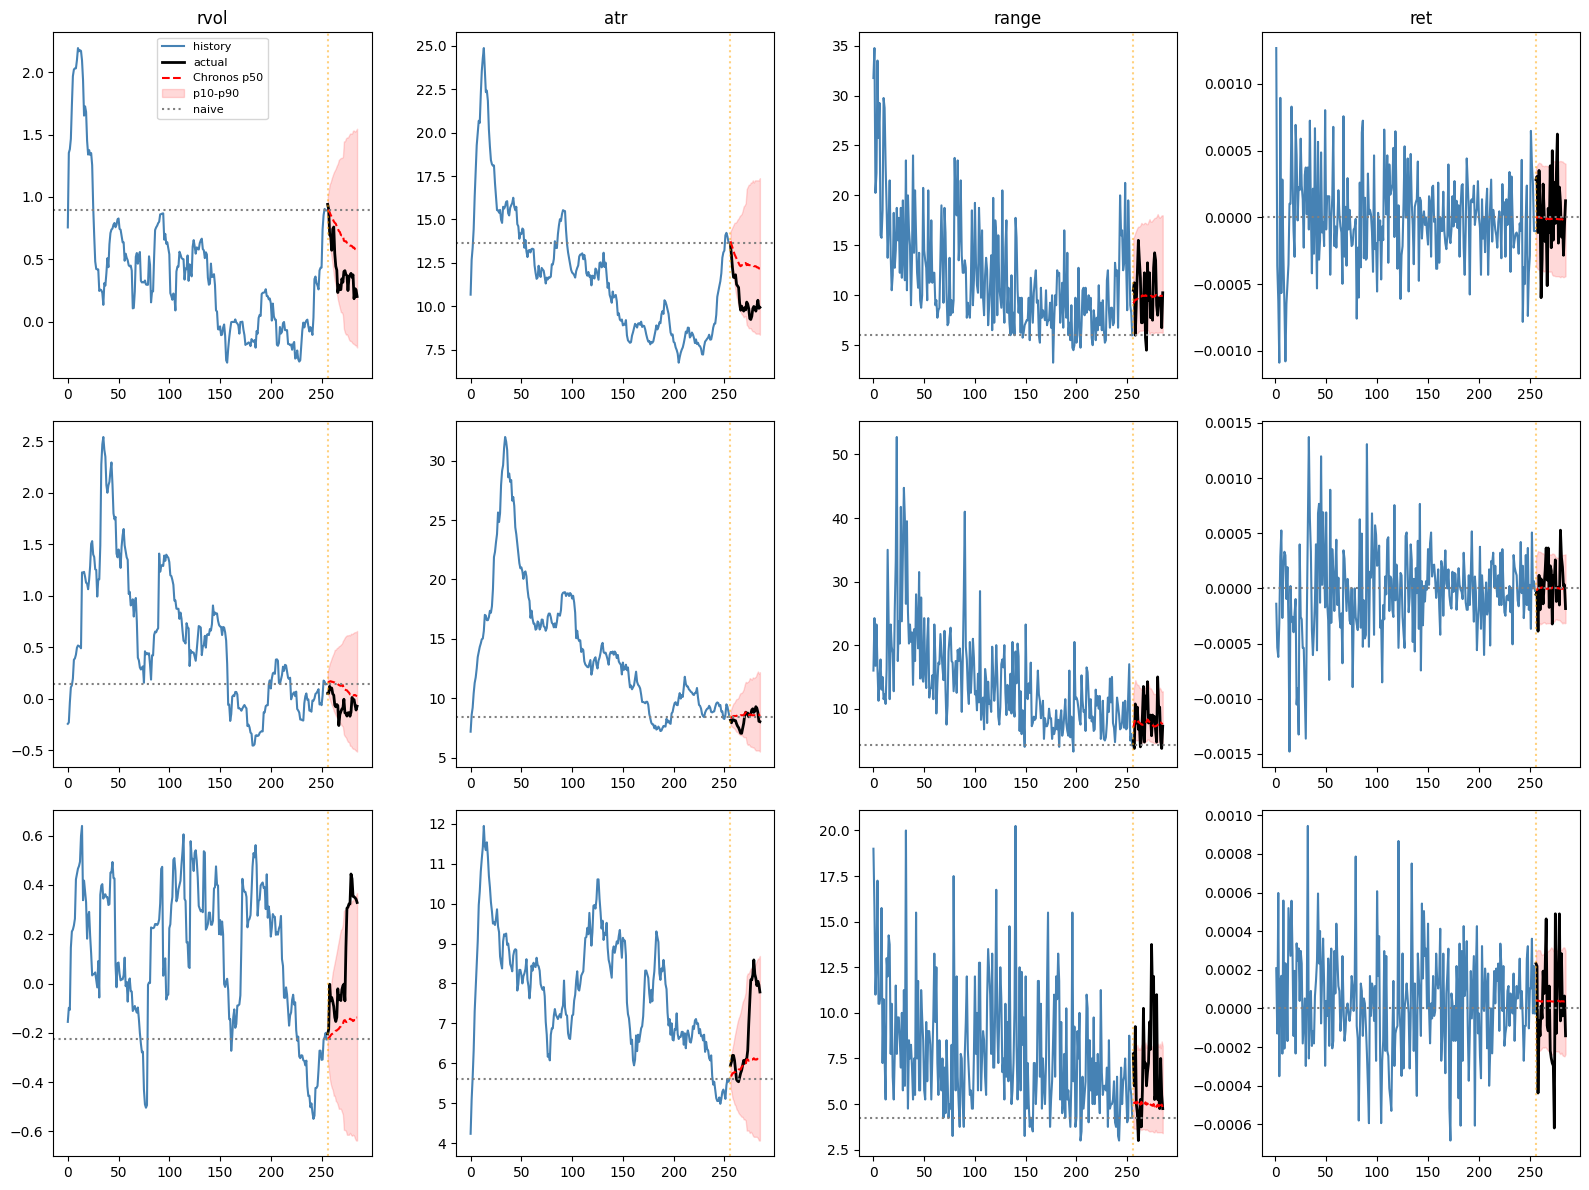


saved chronos_forecast_examples.png


In [15]:
import pyarrow.parquet as pq
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from chronos import Chronos2Pipeline

V38 = "/content/drive/MyDrive/cme_daytrading/mnq_features_full_v38_calendar.parquet"
CONTEXT = 256
HORIZON = 30
USE_COVARIATES = True

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    torch_dtype=torch.bfloat16 if device=="cuda" else torch.float32,
    device_map=device)
print("Chronos-2 loaded")

# ==========================================================
# HAND-PICKED COVARIATES (34 cols, chosen from the real v38 schema)
# Each genuinely predicts forward vol / range / volume / returns.
# NONE are target-twins (no range/vol/atr columns here).
# ==========================================================
COVARIATE_COLS = [
    # — order flow / pressure (predicts vol bursts) —
    'signed_volume_z60','trade_imbalance','vpin_50','vpin_100','vpin_50_change',
    'kyles_lambda_30m','kyles_lambda_change',
    # — liquidity / cost (predicts range & stress) —
    'amihud_illiquidity','mean_spread_z60','spread_twmean','quote_count_z60',
    # — activity intensity (predicts volume & range, strong seasonality) —
    'log_volume','trade_intensity','trade_count_z60','rel_volume','quote_update_rate',
    # — microstructure dynamics / jumps —
    'mean_imbalance_z60','imbalance_twmean','micro_slope','hawkes_lambda_mean','jump_score',
    # — vol-of-vol / volatility regime —
    'vix_30m_close','xa_vvix_level','vol_5m_acceleration','noise_ratio_30m',
    # — time-of-day (drives the U-shaped vol/volume curve) —
    'mod_sin','mod_cos','rth_session_position','mins_to_rth_close',
    # — event proximity (predicts vol spikes) —
    'is_tier1_window_30m',
    # — cross-asset context —
    'xa_vix_level',
]
print(f"hand-picked covariates: {len(COVARIATE_COLS)}")

# ==========================================================
# LOAD
# ==========================================================
load_cols = list(set(['ts','date','close','high','low','realized_vol_15m','is_rth'] + COVARIATE_COLS))
df = pd.read_parquet(V38, columns=load_cols)
df['ts']=pd.to_datetime(df['ts']); df=df.sort_values('ts').reset_index(drop=True)
df['session']=df['date'].astype(str)

df['rvol']=df['realized_vol_15m']
df['atr']=(df['high']-df['low']).rolling(14).mean()
df['range']=(df['high']-df['low'])

# ==========================================================
# RETURN TARGET — corrected placement
# ----------------------------------------------------------
# We model the PER-BAR log return, not the forward cumulative return.
#
# Why not fwd_cumret as a target?
#   fwd_cumret(t) = log(close(t+HORIZON)/close(t)) is forward-looking by
#   construction. Fed as model *history*, the last HORIZON context bars
#   already encode prices inside the forecast window  ->  direct leak.
#   (Session-bounding does NOT remove this; the leak sits at the
#    context/future boundary, not at the session edge.)
#
# The per-bar return is contemporaneous (known at bar t), so it is
# leak-free as history. We reconstruct the forward cumulative return
# AFTERWARDS from the forecast:
#   sum of predicted per-bar returns over the horizon
#     == log(close_end / close_ctx_end)   (telescopes exactly)
#   == the real 30-bar-ahead trade call.
#
# Grouping by (session, is_rth) bounds the return inside each RTH
# session, so it never chains across the overnight gap.
# ==========================================================
df['ret'] = (
    df.groupby(['session','is_rth'])['close']
      .transform(lambda s: np.log(s / s.shift(1)))
)

TARGETS=['rvol','atr','range','ret']

sessions=df[df['is_rth']==True].groupby('session')
eligible=[s for s,g in sessions if len(g)>=CONTEXT+HORIZON]
print(f"eligible sessions: {len(eligible)}")

import random; random.seed(0)
test_sessions=random.sample(eligible, min(40,len(eligible)))

# ==========================================================
# FORECAST LOOP
# ==========================================================
rows=[]; dir_rows=[]; examples=[]
for si,sess in enumerate(test_sessions):
    g=sessions.get_group(sess).reset_index(drop=True)
    ctx=g.iloc[:CONTEXT]; fut=g.iloc[CONTEXT:CONTEXT+HORIZON]

    hist_targets=np.stack([ctx[t].ffill().fillna(0).values for t in TARGETS],axis=0)
    if USE_COVARIATES:
        hist_covs={c: ctx[c].ffill().fillna(0).values.tolist() for c in COVARIATE_COLS}
        input_data=[{"target":hist_targets.tolist(),"past_covariates":hist_covs}]
    else:
        input_data=[{"target":hist_targets.tolist()}]

    fc=pipeline.predict(inputs=input_data, prediction_length=HORIZON, cross_learning=True)
    q_01=fc[0][:,2,:].detach().cpu().numpy()
    q_05=fc[0][:,10,:].detach().cpu().numpy()
    q_09=fc[0][:,18,:].detach().cpu().numpy()

    for ti,t in enumerate(TARGETS):
        actual=fut[t].ffill().fillna(0).values
        chronos_pred=q_05[ti]
        if t=='ret':
            # ---- per-bar return: leak-free direction test ----
            zero_pred=np.zeros(HORIZON)
            rmse_chronos=np.sqrt(np.mean((actual-chronos_pred)**2))
            rmse_zero   =np.sqrt(np.mean((actual-zero_pred)**2))
            mask=actual!=0
            dir_acc_bar=np.mean(np.sign(chronos_pred[mask])==np.sign(actual[mask])) if mask.sum()>0 else np.nan
            # ---- forward cumulative return over the horizon (the real trade call) ----
            # actual.sum() telescopes to log(close_end / close_ctx_end)
            fwd_actual=actual.sum()
            fwd_pred  =chronos_pred.sum()
            dir_acc_cum=float(np.sign(fwd_pred)==np.sign(fwd_actual)) if fwd_actual!=0 else np.nan
            dir_rows.append({'session':sess,
                'dir_acc_bar':dir_acc_bar,'dir_acc_cum':dir_acc_cum,
                'fwd_actual':fwd_actual,'fwd_pred':fwd_pred,
                'rmse_chronos':rmse_chronos,'rmse_zero':rmse_zero,
                'chronos_beats_zero':rmse_chronos<rmse_zero})
        else:
            naive_pred=np.full(HORIZON, ctx[t].iloc[-1])
            denom=np.abs(actual).sum()+1e-9
            rows.append({'session':sess,'target':t,
                'wmape_chronos':np.abs(actual-chronos_pred).sum()/denom,
                'wmape_naive':np.abs(actual-naive_pred).sum()/denom,
                'chronos_beats_naive':np.abs(actual-chronos_pred).sum()<np.abs(actual-naive_pred).sum()})
    if si<3: examples.append((sess,g,q_01,q_05,q_09))
    if (si+1)%10==0: print(f"  {si+1}/{len(test_sessions)} sessions")

# ==========================================================
# RESULTS
# ==========================================================
res=pd.DataFrame(rows)
print("\n========== VOL / ATR / RANGE  (WMAPE vs persistence) ==========")
summ=res.groupby('target').agg(
    wmape_chronos=('wmape_chronos','mean'),wmape_naive=('wmape_naive','mean'),
    win_rate=('chronos_beats_naive','mean')).round(4)
summ['better_by']=(summ['wmape_naive']-summ['wmape_chronos']).round(4)
print(summ.to_string())

dres=pd.DataFrame(dir_rows)
print("\n========== RETURNS — THE REAL TEST (directional accuracy) ==========")
print(f"  per-bar directional accuracy   : {dres['dir_acc_bar'].mean():.4f}   (0.50 = no skill)")
print(f"  per-bar sessions > 0.50        : {(dres['dir_acc_bar']>0.5).mean():.4f}")
print(f"  30-bar CUMULATIVE dir accuracy : {dres['dir_acc_cum'].mean():.4f}   (the actual trade call)")
print(f"  RMSE chronos vs zero (per-bar) : {dres['rmse_chronos'].mean():.6f} vs {dres['rmse_zero'].mean():.6f}")
print(f"  chronos beats zero (RMSE)      : {dres['chronos_beats_zero'].mean():.4f}")
print("\n  INTERPRET: dir_acc ~ 0.50 -> returns NOT forecastable")
print("             dir_acc > 0.53 stable -> surprising; this version is leak-free,")
print("             but still re-check covariates for any forward-looking column.")

# ==========================================================
# VIZ
# ==========================================================
fig,axes=plt.subplots(len(examples),len(TARGETS),figsize=(16,4*len(examples)))
for r,(sess,g,q_01,q_05,q_09) in enumerate(examples):
    for c,t in enumerate(TARGETS):
        ax=axes[r,c] if len(examples)>1 else axes[c]
        ctx=g.iloc[:CONTEXT][t].values; fut=g.iloc[CONTEXT:CONTEXT+HORIZON][t].values
        ax.plot(range(CONTEXT),ctx,color='steelblue',label='history')
        ax.plot(range(CONTEXT,CONTEXT+HORIZON),fut,color='black',label='actual',lw=2)
        ax.plot(range(CONTEXT,CONTEXT+HORIZON),q_05[c],color='red',ls='--',label='Chronos p50')
        ax.fill_between(range(CONTEXT,CONTEXT+HORIZON),q_01[c],q_09[c],color='red',alpha=0.15,label='p10-p90')
        ax.axhline(0 if t=='ret' else ctx[-1],color='gray',ls=':',label='zero' if t=='ret' else 'naive')
        ax.axvline(CONTEXT,color='orange',ls=':',alpha=0.5)
        if r==0: ax.set_title(t)
        if r==0 and c==0: ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('chronos_forecast_examples.png',dpi=100); plt.show()
print("\nsaved chronos_forecast_examples.png")

device: cuda


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 loaded
hand-picked base covariates: 31
eligible sessions: 1187
  10/40 sessions
  20/40 sessions
  30/40 sessions
  40/40 sessions

========== VOL / ATR / RANGE / KALMAN_DIFF  (WMAPE vs persistence) ==========
             wmape_chronos  wmape_naive  win_rate  better_by
target                                                      
atr                 0.1792       0.1851     0.650     0.0059
kalman_diff         1.0547       1.2367     0.675     0.1820
range               0.3467       0.3982     0.775     0.0515
rvol                0.6663       0.6988     0.600     0.0325

========== RETURNS — THE REAL TEST (directional accuracy) ==========
  per-bar directional accuracy   : 0.5120
  30-bar CUMULATIVE dir accuracy : 0.3250


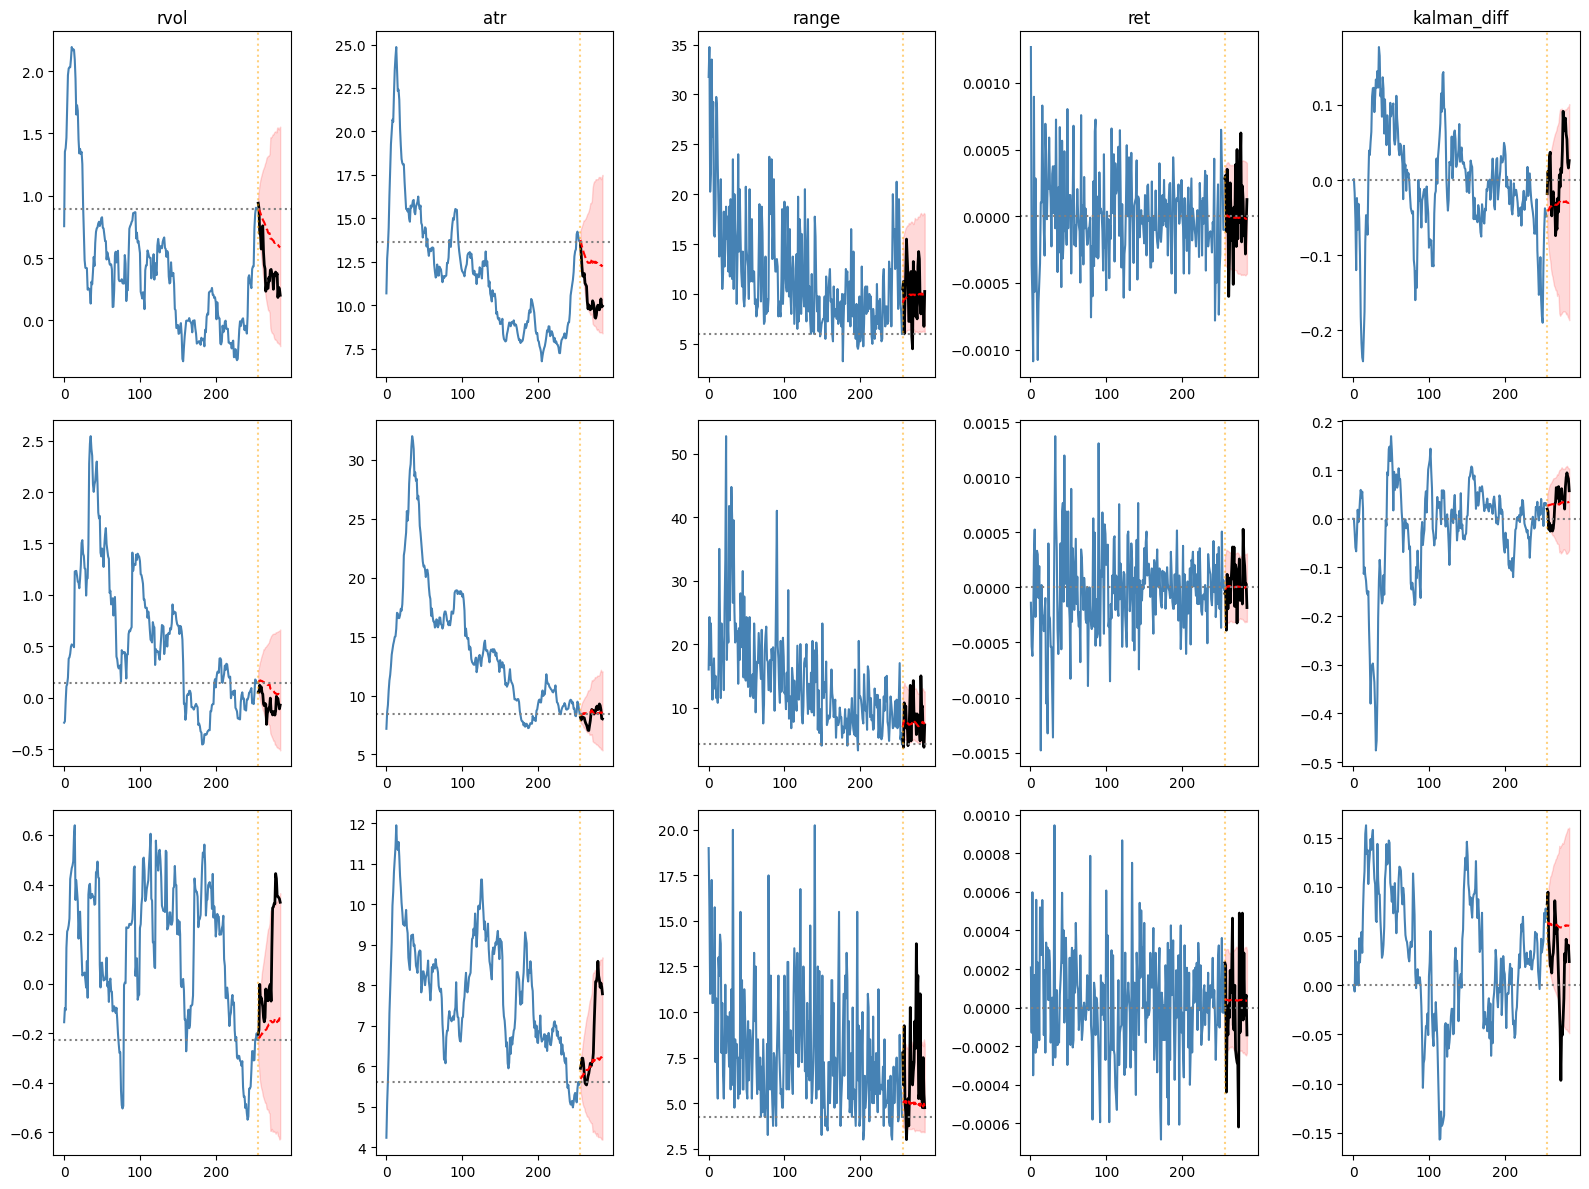

In [18]:
import pyarrow.parquet as pq
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from chronos import Chronos2Pipeline

V38 = "/content/drive/MyDrive/cme_daytrading/mnq_features_full_v38_calendar.parquet"
CONTEXT = 256
HORIZON = 30
USE_COVARIATES = True

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    torch_dtype=torch.bfloat16 if device=="cuda" else torch.float32,
    device_map=device)
print("Chronos-2 loaded")

# ==========================================================
# 1D KALMAN FILTER ENGINE (Vectorized NumPy)
# ==========================================================
def kalman_filter_trend_series(close_prices):
    """Extracts a lag-free trend using a 1D Kalman Filter on a numpy array."""
    n = len(close_prices)
    state_estimate = np.zeros(n)
    error_covariance = np.zeros(n)

    if n == 0:
        return state_estimate

    state_estimate[0] = close_prices[0]
    error_covariance[0] = 1.0

    # Filter parameters tuned for 1-minute frequencies
    process_variance = 1e-4
    measurement_variance = 1e-2

    for t in range(1, n):
        predicted_state = state_estimate[t-1]
        predicted_error_cov = error_covariance[t-1] + process_variance

        kalman_gain = predicted_error_cov / (predicted_error_cov + measurement_variance)
        state_estimate[t] = predicted_state + kalman_gain * (close_prices[t] - predicted_state)
        error_covariance[t] = (1 - kalman_gain) * predicted_error_cov

    return state_estimate

# ==========================================================
# HAND-PICKED COVARIATES
# NOTE: kalman_diff is NOT here — it is now a TARGET (see below).
#       Feeding it as both target and past_covariate would just
#       hand the model the identical past series twice.
# ==========================================================
COVARIATE_COLS = [
    'signed_volume_z60','trade_imbalance','vpin_50','vpin_100','vpin_50_change',
    'kyles_lambda_30m','kyles_lambda_change','amihud_illiquidity','mean_spread_z60',
    'spread_twmean','quote_count_z60','log_volume','trade_intensity','trade_count_z60',
    'rel_volume','quote_update_rate','mean_imbalance_z60','imbalance_twmean',
    'micro_slope','hawkes_lambda_mean','jump_score','vix_30m_close','xa_vvix_level',
    'vol_5m_acceleration','noise_ratio_30m','mod_sin','mod_cos','rth_session_position',
    'mins_to_rth_close','is_tier1_window_30m','xa_vix_level'
]
print(f"hand-picked base covariates: {len(COVARIATE_COLS)}")

# ==========================================================
# LOAD
# ==========================================================
load_cols = list(set(['ts','date','close','high','low','realized_vol_15m','is_rth'] + COVARIATE_COLS))
df = pd.read_parquet(V38, columns=load_cols)
df['ts']=pd.to_datetime(df['ts']); df=df.sort_values('ts').reset_index(drop=True)
df['session']=df['date'].astype(str)

df['rvol']=df['realized_vol_15m']
df['atr']=(df['high']-df['low']).rolling(14).mean()
df['range']=(df['high']-df['low'])

df['ret'] = (
    df.groupby(['session','is_rth'])['close']
      .transform(lambda s: np.log(s / s.shift(1)))
)

# kalman_diff is appended as a TARGET. The column itself is built per
# session inside the loop (so the filter re-initializes at bar 0 of the
# day); the name just needs to exist on `full_session` before slicing.
TARGETS=['rvol','atr','range','ret','kalman_diff']

# Grouping explicitly by the RTH structure
sessions = df[df['is_rth'] == True].groupby('session')
eligible = [s for s, g in sessions if len(g) >= CONTEXT + HORIZON]
print(f"eligible sessions: {len(eligible)}")

import random; random.seed(0)
test_sessions = random.sample(eligible, min(40, len(eligible)))

# ==========================================================
# FORECAST LOOP (With Warm-Up Tracking to Eliminate Filter Distortion)
# ==========================================================
rows=[]; dir_rows=[]; examples=[]
for si, sess in enumerate(test_sessions):
    # 1. Grab the full session array to ensure the filter initializes at bar 0 of the day
    full_session = sessions.get_group(sess).reset_index(drop=True)

    # 2. Run the Kalman Filter across the full session space (causal -> no future leak)
    session_closes = full_session['close'].ffill().fillna(0).values
    session_kalman = kalman_filter_trend_series(session_closes)
    session_kalman_safe = np.where(session_kalman == 0, 1.0, session_kalman)

    full_session['kalman_diff'] = ((session_closes - session_kalman) / session_kalman_safe) * 100

    # 3. NOW safely slice out our target evaluation windows
    ctx = full_session.iloc[:CONTEXT].copy()
    fut = full_session.iloc[CONTEXT:CONTEXT+HORIZON]

    hist_targets = np.stack([ctx[t].ffill().fillna(0).values for t in TARGETS], axis=0)

    if USE_COVARIATES:
        # kalman_diff intentionally excluded here — it is carried as a target row above.
        hist_covs = {c: ctx[c].ffill().fillna(0).values.tolist() for c in COVARIATE_COLS}
        input_data = [{"target": hist_targets.tolist(), "past_covariates": hist_covs}]
    else:
        input_data = [{"target": hist_targets.tolist()}]

    fc = pipeline.predict(inputs=input_data, prediction_length=HORIZON, cross_learning=True)
    q_01 = fc[0][:,2,:].detach().cpu().numpy()
    q_05 = fc[0][:,10,:].detach().cpu().numpy()
    q_09 = fc[0][:,18,:].detach().cpu().numpy()

    for ti, t in enumerate(TARGETS):
        actual = fut[t].ffill().fillna(0).values
        chronos_pred = q_05[ti]
        if t == 'ret':
            zero_pred = np.zeros(HORIZON)
            rmse_chronos = np.sqrt(np.mean((actual-chronos_pred)**2))
            rmse_zero = np.sqrt(np.mean((actual-zero_pred)**2))
            mask = actual != 0
            dir_acc_bar = np.mean(np.sign(chronos_pred[mask]) == np.sign(actual[mask])) if mask.sum() > 0 else np.nan

            fwd_actual = actual.sum()
            fwd_pred = chronos_pred.sum()
            dir_acc_cum = float(np.sign(fwd_pred) == np.sign(fwd_actual)) if fwd_actual != 0 else np.nan
            dir_rows.append({'session': sess,
                'dir_acc_bar': dir_acc_bar, 'dir_acc_cum': dir_acc_cum,
                'fwd_actual': fwd_actual, 'fwd_pred': fwd_pred,
                'rmse_chronos': rmse_chronos, 'rmse_zero': rmse_zero,
                'chronos_beats_zero': rmse_chronos < rmse_zero})
        else:
            # rvol / atr / range / kalman_diff  -> WMAPE vs persistence
            naive_pred = np.full(HORIZON, ctx[t].iloc[-1])
            denom = np.abs(actual).sum() + 1e-9
            rows.append({'session': sess, 'target': t,
                'wmape_chronos': np.abs(actual-chronos_pred).sum() / denom,
                'wmape_naive': np.abs(actual-naive_pred).sum() / denom,
                'chronos_beats_naive': np.abs(actual-chronos_pred).sum() < np.abs(actual-naive_pred).sum()})

    if si < 3: examples.append((sess, full_session, q_01, q_05, q_09))
    if (si+1)%10 == 0: print(f"  {si+1}/{len(test_sessions)} sessions")

# ==========================================================
# RESULTS & VIZ
# ==========================================================
res = pd.DataFrame(rows)
print("\n========== VOL / ATR / RANGE / KALMAN_DIFF  (WMAPE vs persistence) ==========")
summ = res.groupby('target').agg(
    wmape_chronos=('wmape_chronos', 'mean'), wmape_naive=('wmape_naive', 'mean'),
    win_rate=('chronos_beats_naive', 'mean')).round(4)
summ['better_by'] = (summ['wmape_naive'] - summ['wmape_chronos']).round(4)
print(summ.to_string())

dres = pd.DataFrame(dir_rows)
print("\n========== RETURNS — THE REAL TEST (directional accuracy) ==========")
print(f"  per-bar directional accuracy   : {dres['dir_acc_bar'].mean():.4f}")
print(f"  30-bar CUMULATIVE dir accuracy : {dres['dir_acc_cum'].mean():.4f}")

fig, axes = plt.subplots(len(examples), len(TARGETS), figsize=(16, 4*len(examples)))
for r, (sess, g, q_01, q_05, q_09) in enumerate(examples):
    for c, t in enumerate(TARGETS):
        ax = axes[r, c] if len(examples) > 1 else axes[c]
        ctx_vals = g.iloc[:CONTEXT][t].values; fut_vals = g.iloc[CONTEXT:CONTEXT+HORIZON][t].values
        ax.plot(range(CONTEXT), ctx_vals, color='steelblue', label='history')
        ax.plot(range(CONTEXT, CONTEXT+HORIZON), fut_vals, color='black', label='actual', lw=2)
        ax.plot(range(CONTEXT, CONTEXT+HORIZON), q_05[c], color='red', ls='--', label='Chronos p50')
        ax.fill_between(range(CONTEXT, CONTEXT+HORIZON), q_01[c], q_09[c], color='red', alpha=0.15)
        # kalman_diff & ret both oscillate around 0; vol/atr/range use persistence line
        ax.axhline(0 if t in ('ret', 'kalman_diff') else ctx_vals[-1], color='gray', ls=':')
        ax.axvline(CONTEXT, color='orange', ls=':', alpha=0.5)
        if r == 0: ax.set_title(t)
plt.tight_layout(); plt.savefig('chronos_forecast_examples.png', dpi=100); plt.show()

device: cuda


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 loaded
hand-picked base covariates: 31
eligible sessions: 1187
running on 1187 sessions
  25/1187 sessions
  50/1187 sessions
  75/1187 sessions
  100/1187 sessions
  125/1187 sessions
  150/1187 sessions
  175/1187 sessions
  200/1187 sessions
  225/1187 sessions
  250/1187 sessions
  275/1187 sessions
  300/1187 sessions
  325/1187 sessions
  350/1187 sessions
  375/1187 sessions
  400/1187 sessions
  425/1187 sessions
  450/1187 sessions
  475/1187 sessions
  500/1187 sessions
  525/1187 sessions
  550/1187 sessions
  575/1187 sessions
  600/1187 sessions
  625/1187 sessions
  650/1187 sessions
  675/1187 sessions
  700/1187 sessions
  725/1187 sessions
  750/1187 sessions
  775/1187 sessions
  800/1187 sessions
  825/1187 sessions
  850/1187 sessions
  875/1187 sessions
  900/1187 sessions
  925/1187 sessions
  950/1187 sessions
  975/1187 sessions
  1000/1187 sessions
  1025/1187 sessions
  1050/1187 sessions
  1075/1187 sessions
  1100/1187 sessions
  1125/1187 sessions

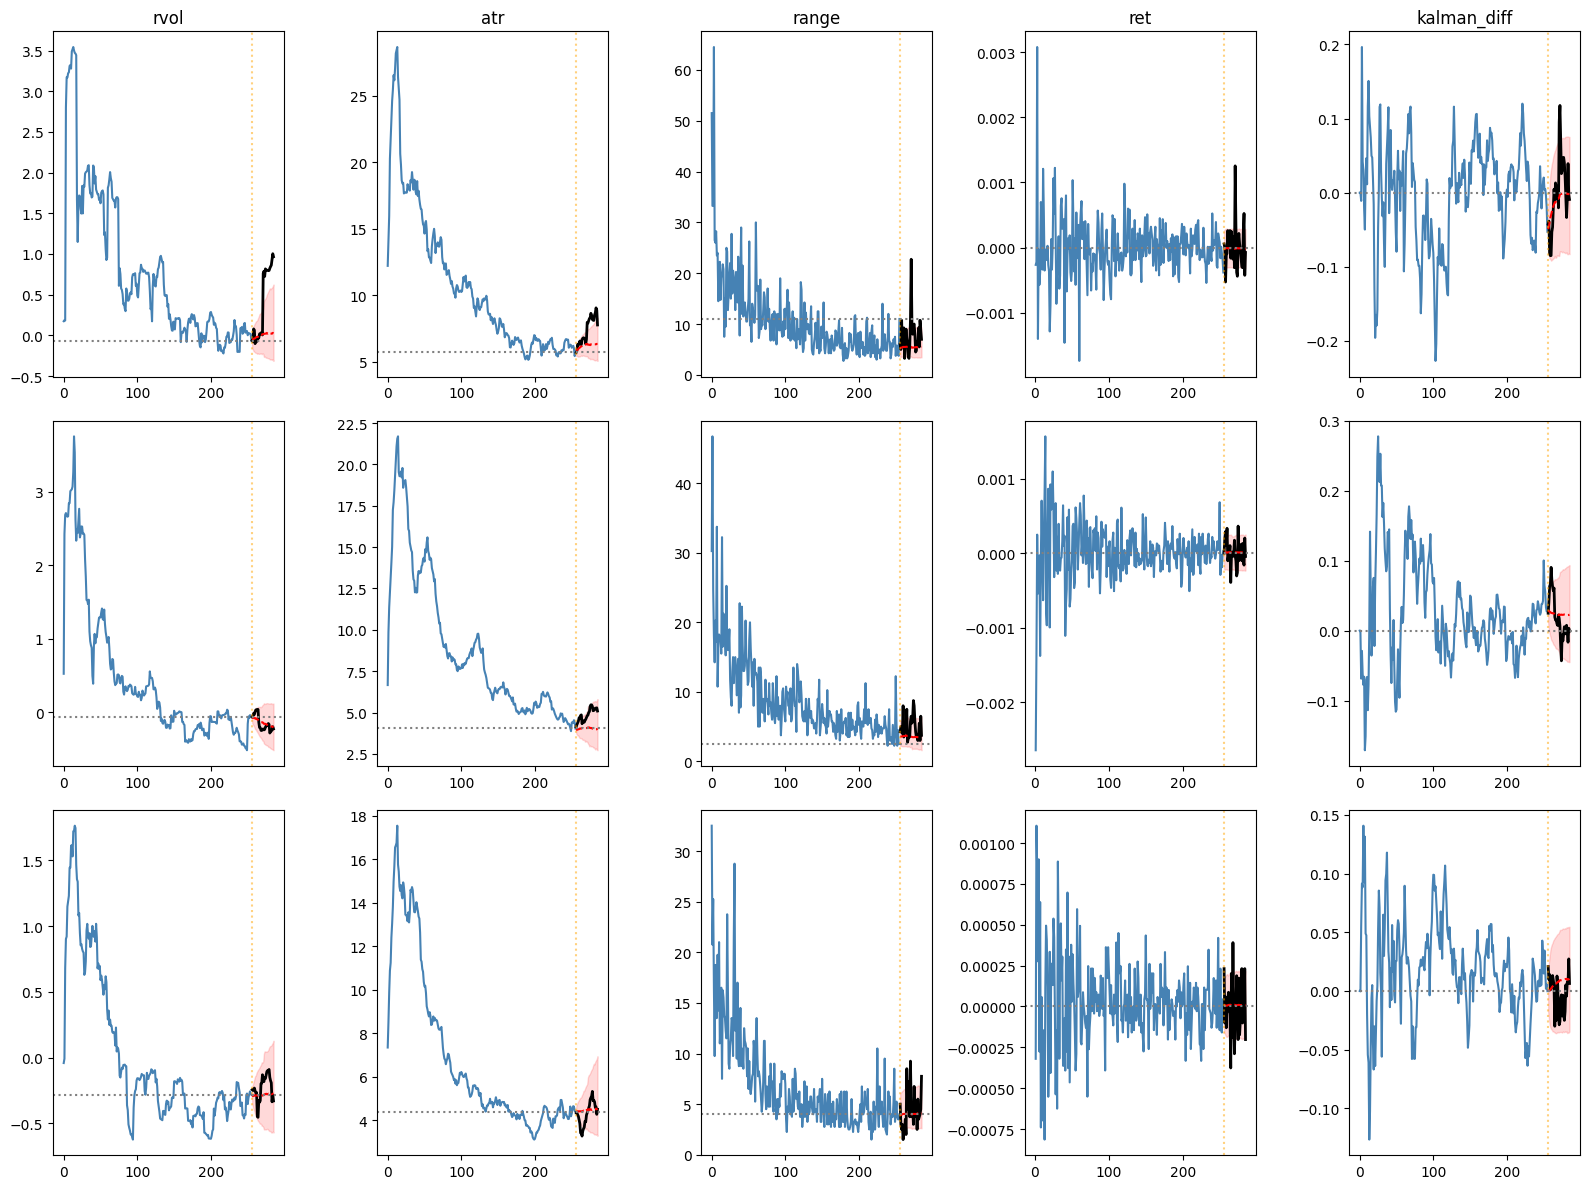

In [20]:
import pyarrow.parquet as pq
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from chronos import Chronos2Pipeline

V38 = "/content/drive/MyDrive/cme_daytrading/mnq_features_full_v38_calendar.parquet"
CONTEXT = 256
HORIZON = 30
USE_COVARIATES = True
MAX_SESSIONS = None   # None = use ALL eligible sessions (full sample). Set an int to cap.
N_BOOT = 2000

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    torch_dtype=torch.bfloat16 if device=="cuda" else torch.float32,
    device_map=device)
print("Chronos-2 loaded")

# ==========================================================
# 1D KALMAN FILTER ENGINE (Vectorized NumPy)
# ==========================================================
def kalman_filter_trend_series(close_prices):
    """Extracts a lag-free trend using a 1D Kalman Filter on a numpy array."""
    n = len(close_prices)
    state_estimate = np.zeros(n)
    error_covariance = np.zeros(n)

    if n == 0:
        return state_estimate

    state_estimate[0] = close_prices[0]
    error_covariance[0] = 1.0

    process_variance = 1e-4
    measurement_variance = 1e-2

    for t in range(1, n):
        predicted_state = state_estimate[t-1]
        predicted_error_cov = error_covariance[t-1] + process_variance
        kalman_gain = predicted_error_cov / (predicted_error_cov + measurement_variance)
        state_estimate[t] = predicted_state + kalman_gain * (close_prices[t] - predicted_state)
        error_covariance[t] = (1 - kalman_gain) * predicted_error_cov

    return state_estimate

# ==========================================================
# BOOTSTRAP HELPERS (resample over sessions -> CI on the metric)
# ==========================================================
def bootstrap_mean(values, n_boot=N_BOOT, seed=0):
    rng = np.random.default_rng(seed)
    v = np.asarray(values, float); v = v[~np.isnan(v)]
    if len(v) == 0: return (np.nan, np.nan, np.nan, 0)
    n = len(v)
    boots = np.array([v[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    return (v.mean(), np.percentile(boots, 2.5), np.percentile(boots, 97.5), n)

def bootstrap_corr(x, y, method='pearson', n_boot=N_BOOT, seed=0):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = ~(np.isnan(x) | np.isnan(y)); x, y = x[m], y[m]
    n = len(x)
    if n < 3: return (np.nan, np.nan, np.nan, n)
    def corr(a, b):
        if method == 'spearman':
            a = pd.Series(a).rank().values; b = pd.Series(b).rank().values
        sa, sb = a.std(), b.std()
        if sa == 0 or sb == 0: return np.nan
        return np.corrcoef(a, b)[0, 1]
    point = corr(x, y)
    boots = np.array([corr(x[i], y[i]) for i in (rng.integers(0, n, n) for _ in range(n_boot))])
    boots = boots[~np.isnan(boots)]
    lo, hi = (np.percentile(boots, 2.5), np.percentile(boots, 97.5)) if len(boots) else (np.nan, np.nan)
    return (point, lo, hi, n)

# ==========================================================
# HAND-PICKED COVARIATES  (kalman_diff is a TARGET, not here)
# ==========================================================
COVARIATE_COLS = [
    'signed_volume_z60','trade_imbalance','vpin_50','vpin_100','vpin_50_change',
    'kyles_lambda_30m','kyles_lambda_change','amihud_illiquidity','mean_spread_z60',
    'spread_twmean','quote_count_z60','log_volume','trade_intensity','trade_count_z60',
    'rel_volume','quote_update_rate','mean_imbalance_z60','imbalance_twmean',
    'micro_slope','hawkes_lambda_mean','jump_score','vix_30m_close','xa_vvix_level',
    'vol_5m_acceleration','noise_ratio_30m','mod_sin','mod_cos','rth_session_position',
    'mins_to_rth_close','is_tier1_window_30m','xa_vix_level'
]
print(f"hand-picked base covariates: {len(COVARIATE_COLS)}")

# ==========================================================
# LOAD
# ==========================================================
load_cols = list(set(['ts','date','close','high','low','realized_vol_15m','is_rth'] + COVARIATE_COLS))
df = pd.read_parquet(V38, columns=load_cols)
df['ts']=pd.to_datetime(df['ts']); df=df.sort_values('ts').reset_index(drop=True)
df['session']=df['date'].astype(str)

df['rvol']=df['realized_vol_15m']
df['atr']=(df['high']-df['low']).rolling(14).mean()
df['range']=(df['high']-df['low'])
df['ret'] = df.groupby(['session','is_rth'])['close'].transform(lambda s: np.log(s / s.shift(1)))

TARGETS=['rvol','atr','range','ret','kalman_diff']

sessions = df[df['is_rth'] == True].groupby('session')
eligible = [s for s, g in sessions if len(g) >= CONTEXT + HORIZON]
print(f"eligible sessions: {len(eligible)}")

# FULL SAMPLE: use every eligible session (no subsampling -> seeds are moot).
test_sessions = eligible if MAX_SESSIONS is None else eligible[:MAX_SESSIONS]
print(f"running on {len(test_sessions)} sessions")

# ==========================================================
# FORECAST LOOP
# ==========================================================
rows=[]; ret_rows=[]; kd_rows=[]; examples=[]
for si, sess in enumerate(test_sessions):
    full_session = sessions.get_group(sess).reset_index(drop=True)

    session_closes = full_session['close'].ffill().fillna(0).values
    session_kalman = kalman_filter_trend_series(session_closes)
    session_kalman_safe = np.where(session_kalman == 0, 1.0, session_kalman)
    full_session['kalman_diff'] = ((session_closes - session_kalman) / session_kalman_safe) * 100

    ctx = full_session.iloc[:CONTEXT].copy()
    fut = full_session.iloc[CONTEXT:CONTEXT+HORIZON]

    hist_targets = np.stack([ctx[t].ffill().fillna(0).values for t in TARGETS], axis=0)
    if USE_COVARIATES:
        hist_covs = {c: ctx[c].ffill().fillna(0).values.tolist() for c in COVARIATE_COLS}
        input_data = [{"target": hist_targets.tolist(), "past_covariates": hist_covs}]
    else:
        input_data = [{"target": hist_targets.tolist()}]

    fc = pipeline.predict(inputs=input_data, prediction_length=HORIZON, cross_learning=True)
    q_01 = fc[0][:,2,:].detach().cpu().numpy()
    q_05 = fc[0][:,10,:].detach().cpu().numpy()
    q_09 = fc[0][:,18,:].detach().cpu().numpy()

    for ti, t in enumerate(TARGETS):
        actual = fut[t].ffill().fillna(0).values
        chronos_pred = q_05[ti]

        if t == 'ret':
            mask = actual != 0
            dir_acc_bar = np.mean(np.sign(chronos_pred[mask]) == np.sign(actual[mask])) if mask.sum() > 0 else np.nan
            fwd_actual = actual.sum(); fwd_pred = chronos_pred.sum()
            dir_acc_cum = float(np.sign(fwd_pred) == np.sign(fwd_actual)) if fwd_actual != 0 else np.nan
            ret_rows.append({'session': sess,
                'dir_acc_bar': dir_acc_bar, 'dir_acc_cum': dir_acc_cum,
                'fwd_actual': fwd_actual, 'fwd_pred': fwd_pred})

# --- inside the loop, REPLACE the elif t == 'kalman_diff' block with: ---
        elif t == 'kalman_diff':
            kd_now    = ctx['kalman_diff'].iloc[-1]
            kd_actual = actual
            kd_pred   = chronos_pred

            d_actual = np.diff(np.concatenate([[kd_now], kd_actual]))
            d_pred   = np.diff(np.concatenate([[kd_now], kd_pred]))
            m = d_actual != 0
            dir_acc_bar_kd = np.mean(np.sign(d_pred[m]) == np.sign(d_actual[m])) if m.sum() > 0 else np.nan

            net_actual = kd_actual[-1] - kd_now
            net_pred   = kd_pred[-1]   - kd_now
            dir_acc_net = float(np.sign(net_pred) == np.sign(net_actual)) if net_actual != 0 else np.nan

            # trivial control: "fade kd_now" needs no model — predicts full reversion to 0
            net_naive = -kd_now
            dir_acc_net_naive = float(np.sign(net_naive) == np.sign(net_actual)) if net_actual != 0 else np.nan

            actual_revert = float(abs(kd_actual[-1]) < abs(kd_now))
            pred_revert   = float(abs(kd_pred[-1])   < abs(kd_now))
            revert_match  = float(pred_revert == actual_revert)

            kd_rows.append({'session': sess,
                'dir_acc_bar': dir_acc_bar_kd,
                'dir_acc_net': dir_acc_net, 'dir_acc_net_naive': dir_acc_net_naive,
                'revert_match': revert_match, 'actual_revert': actual_revert,
                'net_pred': net_pred, 'net_actual': net_actual, 'net_naive': net_naive})

        else:  # rvol / atr / range -> WMAPE vs persistence
            naive_pred = np.full(HORIZON, ctx[t].iloc[-1])
            denom = np.abs(actual).sum() + 1e-9
            rows.append({'session': sess, 'target': t,
                'wmape_chronos': np.abs(actual-chronos_pred).sum() / denom,
                'wmape_naive': np.abs(actual-naive_pred).sum() / denom,
                'chronos_beats_naive': np.abs(actual-chronos_pred).sum() < np.abs(actual-naive_pred).sum()})

    if si < 3: examples.append((sess, full_session, q_01, q_05, q_09))
    if (si+1) % 25 == 0: print(f"  {si+1}/{len(test_sessions)} sessions")

# ==========================================================
# RESULTS
# ==========================================================
res = pd.DataFrame(rows)
print("\n========== VOL / ATR / RANGE  (WMAPE vs persistence) ==========")
summ = res.groupby('target').agg(
    wmape_chronos=('wmape_chronos','mean'), wmape_naive=('wmape_naive','mean'),
    win_rate=('chronos_beats_naive','mean')).round(4)
summ['better_by'] = (summ['wmape_naive'] - summ['wmape_chronos']).round(4)
print(summ.to_string())

# ---- RETURNS ----
rdf = pd.DataFrame(ret_rows)
db = bootstrap_mean(rdf['dir_acc_bar']); dc = bootstrap_mean(rdf['dir_acc_cum'])
pr = bootstrap_corr(rdf['fwd_pred'], rdf['fwd_actual'], 'pearson')
sr = bootstrap_corr(rdf['fwd_pred'], rdf['fwd_actual'], 'spearman')
print("\n========== RETURNS — full sample, bootstrap 95% CI ==========")
print(f"  per-bar directional acc : {db[0]:.4f}   [{db[1]:.4f}, {db[2]:.4f}]   (n={db[3]})")
print(f"  30-bar cumulative dir acc: {dc[0]:.4f}   [{dc[1]:.4f}, {dc[2]:.4f}]   (n={dc[3]})")
print(f"  corr(fwd_pred, fwd_actual) Pearson : {pr[0]:.4f}   [{pr[1]:.4f}, {pr[2]:.4f}]   (n={pr[3]})")
print(f"  corr(fwd_pred, fwd_actual) Spearman: {sr[0]:.4f}   [{sr[1]:.4f}, {sr[2]:.4f}]")
print("  READ: CI crossing 0.50 (dir) or 0.0 (corr) => consistent with no skill / noise.")
print("        corr stably NEGATIVE => model's net call is being faded (mean reversion).")

# ---- KALMAN_DIFF (reversion direction) ----
# --- REPLACE the KALMAN_DIFF results block with: ---
kdf = pd.DataFrame(kd_rows)
kb  = bootstrap_mean(kdf['dir_acc_bar'])
kn  = bootstrap_mean(kdf['dir_acc_net'])
kn0 = bootstrap_mean(kdf['dir_acc_net_naive'])
krm = bootstrap_mean(kdf['revert_match'])
base= kdf['actual_revert'].mean()
kpr = bootstrap_corr(kdf['net_pred'],  kdf['net_actual'], 'pearson')
kp0 = bootstrap_corr(kdf['net_naive'], kdf['net_actual'], 'pearson')
print("\n========== KALMAN_DIFF — reversion scoring vs trivial 'fade kd_now' baseline ==========")
print(f"  per-bar change dir acc        : {kb[0]:.4f}   [{kb[1]:.4f}, {kb[2]:.4f}]")
print(f"  net dir  CHRONOS              : {kn[0]:.4f}   [{kn[1]:.4f}, {kn[2]:.4f}]")
print(f"  net dir  FADE-kd_now (naive)  : {kn0[0]:.4f}   [{kn0[1]:.4f}, {kn0[2]:.4f}]")
print(f"    --> Chronos lift over naive : {kn[0]-kn0[0]:+.4f}")
print(f"  reversion-call CHRONOS        : {krm[0]:.4f}   [{krm[1]:.4f}, {krm[2]:.4f}]   (base {base:.4f})")
print(f"  corr net_pred  vs actual      : {kpr[0]:.4f}   [{kpr[1]:.4f}, {kpr[2]:.4f}]")
print(f"  corr net_naive vs actual      : {kp0[0]:.4f}   [{kp0[1]:.4f}, {kp0[2]:.4f}]")
print("  READ: if Chronos net-dir ~ naive net-dir, the 'skill' is kd_now, not the model.")

# ==========================================================
# VIZ
# ==========================================================
fig, axes = plt.subplots(len(examples), len(TARGETS), figsize=(16, 4*len(examples)))
for r, (sess, g, q_01, q_05, q_09) in enumerate(examples):
    for c, t in enumerate(TARGETS):
        ax = axes[r, c] if len(examples) > 1 else axes[c]
        ctx_vals = g.iloc[:CONTEXT][t].values; fut_vals = g.iloc[CONTEXT:CONTEXT+HORIZON][t].values
        ax.plot(range(CONTEXT), ctx_vals, color='steelblue', label='history')
        ax.plot(range(CONTEXT, CONTEXT+HORIZON), fut_vals, color='black', label='actual', lw=2)
        ax.plot(range(CONTEXT, CONTEXT+HORIZON), q_05[c], color='red', ls='--', label='Chronos p50')
        ax.fill_between(range(CONTEXT, CONTEXT+HORIZON), q_01[c], q_09[c], color='red', alpha=0.15)
        ax.axhline(0 if t in ('ret', 'kalman_diff') else ctx_vals[-1], color='gray', ls=':')
        ax.axvline(CONTEXT, color='orange', ls=':', alpha=0.5)
        if r == 0: ax.set_title(t)
plt.tight_layout(); plt.savefig('chronos_forecast_examples.png', dpi=100); plt.show()

In [4]:
import pyarrow.parquet as pq
import numpy as np, pandas as pd, torch
from chronos import Chronos2Pipeline
from scipy import stats

V38 = "/content/drive/MyDrive/cme_daytrading/mnq_features_full_v38_calendar.parquet"
CONTEXT = 256
HORIZON = 30
N_SESSIONS = 200          # scaled up from 40

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    torch_dtype=torch.bfloat16 if device=="cuda" else torch.float32,
    device_map=device)
print("Chronos-2 loaded")

COVARIATE_COLS = [
    'signed_volume_z60','trade_imbalance','vpin_50','vpin_100','vpin_50_change',
    'kyles_lambda_30m','kyles_lambda_change','cvd_30m','voi_sum',
    'amihud_illiquidity','mean_spread_z60','spread_twmean','quote_count_z60',
    'log_volume','trade_intensity','trade_count_z60','rel_volume','quote_update_rate',
    'mean_imbalance_z60','imbalance_twmean','micro_slope','hawkes_lambda_mean','jump_score',
    'vix_30m_close','xa_vvix_level','vol_5m_acceleration','noise_ratio_30m',
    'mod_sin','mod_cos','rth_session_position','mins_to_rth_close',
    'is_tier1_window_30m','xa2_qqq_ret5m','xa_vix_level',
]

load_cols = list(set(['ts','date','close','high','low','realized_vol_15m','is_rth','vix_30m_close'] + COVARIATE_COLS))
df = pd.read_parquet(V38, columns=load_cols)
df['ts']=pd.to_datetime(df['ts']); df=df.sort_values('ts').reset_index(drop=True)
df['session']=df['date'].astype(str)
df['year']=df['ts'].dt.year

df['rvol']=df['realized_vol_15m']
df['atr']=(df['high']-df['low']).rolling(14).mean()
df['range']=(df['high']-df['low'])
df['returns']=(np.log(df['close']/df['close'].shift(1)).fillna(0))*100
TARGETS=['rvol','atr','range','returns']

# ── per-session VIX regime (median split) for stratification ──
sess_vix = df.groupby('session')['vix_30m_close'].median()
vix_thresh = sess_vix.median()
print(f"VIX regime split at {vix_thresh:.1f}")

sessions=df[df['is_rth']==True].groupby('session')
eligible=[s for s,g in sessions if len(g)>=CONTEXT+HORIZON]
print(f"eligible sessions: {len(eligible)}")

# ── STRATIFIED sample: spread across years (not just random 40) ──
import random; random.seed(0)
elig_df = pd.DataFrame({'session':eligible})
elig_df['year'] = elig_df['session'].map(lambda s: pd.to_datetime(s).year)
per_year = max(1, N_SESSIONS // elig_df['year'].nunique())
test_sessions=[]
for yr,grp in elig_df.groupby('year'):
    test_sessions += random.sample(list(grp['session']), min(per_year, len(grp)))
print(f"sampled {len(test_sessions)} sessions across {elig_df['year'].nunique()} years")

# ==========================================================
# FORECAST LOOP
# ==========================================================
rows=[]; dir_rows=[]
for si,sess in enumerate(test_sessions):
    g=sessions.get_group(sess).reset_index(drop=True)
    ctx=g.iloc[:CONTEXT]; fut=g.iloc[CONTEXT:CONTEXT+HORIZON]
    yr=pd.to_datetime(sess).year
    vix_reg = 'high_vix' if sess_vix.get(sess,vix_thresh)>=vix_thresh else 'low_vix'

    hist_targets=np.stack([ctx[t].ffill().fillna(0).values for t in TARGETS],axis=0)
    hist_covs={c: ctx[c].ffill().fillna(0).values.tolist() for c in COVARIATE_COLS}
    input_data=[{"target":hist_targets.tolist(),"past_covariates":hist_covs}]
    try:
        fc=pipeline.predict(inputs=input_data, prediction_length=HORIZON, cross_learning=True)
    except Exception as e:
        print(f"  skip {sess}: {e}"); continue
    q_05=fc[0][:,10,:].detach().cpu().numpy()

    for ti,t in enumerate(TARGETS):
        actual=fut[t].ffill().fillna(0).values
        pred=q_05[ti]
        if t=='returns':
            zero=np.zeros(HORIZON)
            mask=actual!=0
            dir_acc=np.mean(np.sign(pred[mask])==np.sign(actual[mask])) if mask.sum()>0 else np.nan
            n_correct=int((np.sign(pred[mask])==np.sign(actual[mask])).sum()); n_tot=int(mask.sum())
            dir_rows.append({'session':sess,'year':yr,'vix_reg':vix_reg,'dir_acc':dir_acc,
                'n_correct':n_correct,'n_tot':n_tot,
                'rmse_chronos':np.sqrt(np.mean((actual-pred)**2)),
                'rmse_zero':np.sqrt(np.mean((actual-zero)**2))})
        else:
            naive=np.full(HORIZON, ctx[t].iloc[-1]); denom=np.abs(actual).sum()+1e-9
            rows.append({'session':sess,'year':yr,'vix_reg':vix_reg,'target':t,
                'wmape_chronos':np.abs(actual-pred).sum()/denom,
                'wmape_naive':np.abs(actual-naive).sum()/denom,
                'beats':np.abs(actual-pred).sum()<np.abs(actual-naive).sum()})
    if (si+1)%25==0: print(f"  {si+1}/{len(test_sessions)} sessions")

res=pd.DataFrame(rows); dres=pd.DataFrame(dir_rows)
res.to_csv("/content/chronos_scaled_magnitude.csv",index=False)
dres.to_csv("/content/chronos_scaled_returns.csv",index=False)

# ==========================================================
# MAGNITUDE RESULTS — overall, by year, by VIX regime
# ==========================================================
print(f"\n{'='*70}\nMAGNITUDE (range/rvol/atr) — n={res['session'].nunique()} sessions\n{'='*70}")
print("\nOVERALL:")
ov=res.groupby('target').agg(win_rate=('beats','mean'),
    wmape_chronos=('wmape_chronos','mean'),wmape_naive=('wmape_naive','mean')).round(4)
ov['better_by']=(ov['wmape_naive']-ov['wmape_chronos']).round(4); print(ov.to_string())
print("\nBY YEAR (win_rate):")
print(res.pivot_table(index='target',columns='year',values='beats',aggfunc='mean').round(3).to_string())
print("\nBY VIX REGIME (win_rate):")
print(res.pivot_table(index='target',columns='vix_reg',values='beats',aggfunc='mean').round(3).to_string())

# ==========================================================
# RETURNS — the definitive close: distribution + binomial test
# ==========================================================
print(f"\n{'='*70}\nRETURNS — definitive efficient-market test — n={len(dres)} sessions\n{'='*70}")
print(f"  mean directional accuracy : {dres['dir_acc'].mean():.4f}")
print(f"  std across sessions       : {dres['dir_acc'].std():.4f}")
print(f"  sessions > 0.50           : {(dres['dir_acc']>0.5).mean():.4f}")
print(f"  sessions > 0.55           : {(dres['dir_acc']>0.55).mean():.4f}")
# pooled binomial test: total correct sign predictions vs 50%
tot_correct=dres['n_correct'].sum(); tot=dres['n_tot'].sum()
binom_p=stats.binomtest(tot_correct, tot, 0.5).pvalue if tot>0 else np.nan
print(f"  POOLED: {tot_correct:,}/{tot:,} = {tot_correct/tot:.4f} correct")
print(f"  binomial test vs 0.50, p-value = {binom_p:.4f}")
print(f"  → p>0.05 means indistinguishable from coin-flip (returns NOT forecastable)")
print("\n  RETURNS dir_acc BY YEAR:")
print(dres.groupby('year')['dir_acc'].agg(['mean','count']).round(4).to_string())
print("\n  RETURNS dir_acc BY VIX REGIME:")
print(dres.groupby('vix_reg')['dir_acc'].agg(['mean','count']).round(4).to_string())
print("\n[DONE] saved chronos_scaled_magnitude.csv, chronos_scaled_returns.csv")

device: cuda


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 loaded
VIX regime split at 25.6
eligible sessions: 1187
sampled 198 sessions across 6 years
  25/198 sessions
  50/198 sessions
  75/198 sessions
  100/198 sessions
  125/198 sessions
  150/198 sessions
  175/198 sessions

MAGNITUDE (range/rvol/atr) — n=198 sessions

OVERALL:
        win_rate  wmape_chronos  wmape_naive  better_by
target                                                 
atr       0.5152         0.1528       0.1528     0.0000
range     0.7475         0.3169       0.4130     0.0961
rvol      0.5404         0.8151       0.7958    -0.0193

BY YEAR (win_rate):
year     2021   2022   2023   2024   2025   2026
target                                          
atr     0.394  0.545  0.545  0.455  0.606  0.545
range   0.727  0.727  0.818  0.788  0.636  0.788
rvol    0.515  0.394  0.636  0.515  0.606  0.576

BY VIX REGIME (win_rate):
vix_reg  high_vix  low_vix
target                    
atr         0.515    0.515
range       0.743    0.753
rvol        0.505    0.577

RETU

In [2]:
"""
overfit_guards.py
Two guards against the selection bias introduced by the per-origin champion search.

DSR  (Deflated Sharpe Ratio): probability the champion's Sharpe is > 0 AFTER
     correcting for (a) the number of trials searched, and (b) skew/kurtosis of
     the return series. Bailey & Lopez de Prado (2014).

PBO  (Probability of Backtest Overfitting): via combinatorially-symmetric
     cross-validation (CSCV). Split the per-trial return matrix into S blocks,
     for every train/test partition pick the in-sample best strategy and see
     where it ranks out-of-sample. PBO = P(OOS rank below median). Bailey et al.
"""
import numpy as np
from scipy.stats import norm
from itertools import combinations


# ----------------------------- Deflated Sharpe -----------------------------
def sharpe_se(sr, n, skew, kurt):
    # standard error of the Sharpe estimator under non-normal returns
    return np.sqrt((1 - skew * sr + (kurt - 1) / 4 * sr ** 2) / (n - 1))

def expected_max_sharpe(sr_trials):
    """E[max Sharpe] of N independent zero-true-Sharpe trials, from their dispersion."""
    sr_trials = np.asarray(sr_trials, float)
    sr_trials = sr_trials[np.isfinite(sr_trials)]
    N = len(sr_trials)
    if N < 2:
        return 0.0
    v = np.var(sr_trials, ddof=1)
    if v <= 0:
        return 0.0
    e = np.e; g = 0.5772156649  # Euler-Mascheroni
    z1 = norm.ppf(1 - 1.0 / N)
    z2 = norm.ppf(1 - 1.0 / (N * e))
    return np.sqrt(v) * ((1 - g) * z1 + g * z2)

def deflated_sharpe_ratio(champion_returns, all_trial_sharpes, periods_per_year=252):
    """
    champion_returns : 1-D OOS (or holdout) return series of the SELECTED strategy
    all_trial_sharpes: per-period (NOT annualized) Sharpes of EVERY trial you searched
    Returns dict with the deflated SR (a probability in [0,1]) and pieces.
    """
    r = np.asarray(champion_returns, float); r = r[np.isfinite(r)]
    n = len(r)
    mu, sd = r.mean(), r.std(ddof=1)
    sr = mu / sd if sd > 0 else 0.0                      # per-period Sharpe of champion
    from scipy.stats import skew as sk, kurtosis as ku
    g3, g4 = sk(r), ku(r, fisher=False)                  # skew, NON-excess kurtosis
    sr0 = expected_max_sharpe(all_trial_sharpes)         # benchmark Sharpe from N trials
    se  = sharpe_se(sr, n, g3, g4)
    dsr = norm.cdf((sr - sr0) / se) if se > 0 else np.nan
    ann = lambda s: s * np.sqrt(periods_per_year)
    return {'DSR': dsr, 'champion_sr_ann': ann(sr), 'benchmark_sr_ann': ann(sr0),
            'n_trials': int(np.isfinite(np.asarray(all_trial_sharpes, float)).sum()),
            'skew': g3, 'kurtosis': g4, 'n_obs': n,
            'verdict': ('real' if (np.isfinite(dsr) and dsr > 0.95)
                        else 'NOT significant after deflation')}


# ----------------------------- PBO via CSCV -----------------------------
def pbo_cscv(returns_matrix, S=10):
    """
    returns_matrix : shape (T, K). Column k = per-period return series of trial k
                     (the K configs you searched), aligned in time.
    S              : even number of time blocks. All C(S, S/2) train/test splits used.
    Returns dict with PBO and the logit distribution.
    """
    R = np.asarray(returns_matrix, float)
    T, K = R.shape
    if K < 2:
        return {'PBO': np.nan, 'note': 'need >=2 trials'}
    S -= S % 2                                            # force even
    idx = np.array_split(np.arange(T), S)
    blocks = [b for b in idx if len(b)]
    S = len(blocks)
    half = S // 2
    sharpe = lambda x: x.mean() / x.std(ddof=1) if x.std(ddof=1) > 0 else 0.0

    logits = []
    for train_sel in combinations(range(S), half):
        tr = np.concatenate([blocks[i] for i in train_sel])
        te = np.concatenate([blocks[i] for i in range(S) if i not in train_sel])
        is_perf  = np.array([sharpe(R[tr, k]) for k in range(K)])
        oos_perf = np.array([sharpe(R[te, k]) for k in range(K)])
        best = int(np.argmax(is_perf))                   # chosen in-sample
        # OOS relative rank of the in-sample best (1 = best OOS, 0 = worst OOS)
        rank = (oos_perf < oos_perf[best]).sum() / (K - 1) if K > 1 else 0.5
        w = min(max(rank, 1e-6), 1 - 1e-6)
        logits.append(np.log(w / (1 - w)))
    logits = np.array(logits)
    pbo = float(np.mean(logits <= 0))                    # P(OOS rank below median)
    return {'PBO': pbo, 'n_splits': len(logits), 'mean_logit': float(logits.mean()),
            'verdict': ('robust' if pbo < 0.5 else 'OVERFIT (selection does not generalize)')}


if __name__ == "__main__":
    rng = np.random.default_rng(0)
    # 24 pure-noise trials over 600 periods -> DSR should fail, PBO should be ~0.5
    M = rng.normal(0, 0.01, size=(600, 24))
    champ = M[:, M.mean(0).argmax()]
    sr_trials = M.mean(0) / M.std(0, ddof=1)
    print(deflated_sharpe_ratio(champ, sr_trials, 252))
    print(pbo_cscv(M, S=10))

{'DSR': np.float64(0.7172337779955602), 'champion_sr_ann': np.float64(1.5445589402311686), 'benchmark_sr_ann': np.float64(1.1702372117898783), 'n_trials': 24, 'skew': np.float64(-0.040486888179794844), 'kurtosis': np.float64(2.9696874611253343), 'n_obs': 600, 'verdict': 'NOT significant after deflation'}
{'PBO': 0.5119047619047619, 'n_splits': 252, 'mean_logit': -0.3884119406048909, 'verdict': 'OVERFIT (selection does not generalize)'}


In [3]:
"""
quant_perf_measures.py
Performance metrics transcribed from the user's library, plus evaluate_all().
One bug fixed: max_consecutive_wins_losses (original streak logic was incorrect).
Each metric is wrapped in evaluate_all() with try/except so a single failure
doesn't kill the whole report.
"""
import numpy as np
import pandas as pd
from scipy import stats
from collections import OrderedDict


def total_return(returns):
    return np.prod(1 + returns) - 1

def annualized_return(returns, periods_per_year):
    tr = np.prod(1 + returns) - 1
    return (1 + tr) ** (periods_per_year / len(returns)) - 1

def sharpe_ratio(returns, risk_free_rate, periods_per_year):
    ex = returns - risk_free_rate
    sd = ex.std()
    return np.sqrt(periods_per_year) * ex.mean() / sd if sd > 0 else np.nan

def sortino_ratio(returns, risk_free_rate, periods_per_year):
    ex = returns - risk_free_rate
    dn = np.minimum(ex, 0)
    d = np.std(dn)
    return np.sqrt(periods_per_year) * ex.mean() / d if d > 0 else np.nan

def maximum_drawdown(returns):
    cum = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(cum)
    dd = (cum - peak) / peak
    return np.min(dd)

def calmar_ratio(returns, periods_per_year):
    mdd = abs(maximum_drawdown(returns))
    return annualized_return(returns, periods_per_year) / mdd if mdd > 0 else np.nan

def information_ratio(returns, benchmark_returns, periods_per_year):
    act = returns - benchmark_returns
    sd = act.std()
    return np.sqrt(periods_per_year) * act.mean() / sd if sd > 0 else np.nan

def beta(returns, benchmark_returns):
    v = np.var(benchmark_returns)
    return np.cov(returns, benchmark_returns)[0, 1] / v if v > 0 else np.nan

def alpha(returns, benchmark_returns, risk_free_rate):
    ex = returns - risk_free_rate
    exb = benchmark_returns - risk_free_rate
    b = beta(returns, benchmark_returns)
    return ex.mean() - b * exb.mean()

def treynor_ratio(returns, benchmark_returns, risk_free_rate, periods_per_year):
    ex = returns - risk_free_rate
    b = beta(returns, benchmark_returns)
    return np.sqrt(periods_per_year) * ex.mean() / b if b and b != 0 else np.nan

def value_at_risk(returns, confidence_level=0.95):
    return np.percentile(returns, 100 * (1 - confidence_level))

def conditional_value_at_risk(returns, confidence_level=0.95):
    var = value_at_risk(returns, confidence_level)
    tail = returns[returns <= var]
    return tail.mean() if len(tail) else np.nan

def omega_ratio(returns, threshold):
    up = np.mean(np.maximum(returns - threshold, 0))
    dn = np.mean(np.maximum(threshold - returns, 0))
    return up / dn if dn > 0 else np.nan

def kappa_ratio(returns, threshold, n):
    lpm = np.mean(np.maximum(threshold - returns, 0) ** n)
    return (np.mean(returns) - threshold) / (lpm ** (1 / n)) if lpm > 0 else np.nan

def upside_potential_ratio(returns, threshold):
    up = np.maximum(returns - threshold, 0)
    dn = np.maximum(threshold - returns, 0)
    d = np.sqrt(np.mean(dn ** 2))
    return np.mean(up) / d if d > 0 else np.nan

def gain_loss_ratio(returns):
    g = returns[returns > 0]; l = returns[returns < 0]
    return np.mean(g) / abs(np.mean(l)) if len(l) and np.mean(l) != 0 else np.nan

def ulcer_index(returns):
    cum = np.cumprod(1 + returns)
    dd = 1 - cum / np.maximum.accumulate(cum)
    return np.sqrt(np.mean(dd ** 2))

def pain_index(returns):
    cum = np.cumprod(1 + returns)
    dd = 1 - cum / np.maximum.accumulate(cum)
    return np.mean(dd)

def pain_ratio(returns, risk_free_rate, periods_per_year):
    pi = pain_index(returns)
    return (annualized_return(returns, periods_per_year) - risk_free_rate) / pi if pi > 0 else np.nan

def martin_ratio(returns, risk_free_rate, periods_per_year):
    ui = ulcer_index(returns)
    return (annualized_return(returns, periods_per_year) - risk_free_rate) / ui if ui > 0 else np.nan

def skewness(returns):
    return stats.skew(returns)

def kurtosis(returns):
    return stats.kurtosis(returns)

def jarque_bera_stat(returns):
    return stats.jarque_bera(returns)[0]

def hurst_exponent(returns, lags=range(2, 100)):
    returns = np.asarray(returns, float)
    lags = [l for l in lags if l < len(returns)]
    if len(lags) < 2:
        return np.nan
    tau = [np.sqrt(np.std(returns[lag:] - returns[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0] * 2.0

def autocorrelation(returns, lag=1):
    return pd.Series(returns).autocorr(lag)

def max_consecutive_wins_losses(returns):
    """Fixed: longest run of >=0 and of <0."""
    wins = max_run(returns >= 0)
    losses = max_run(returns < 0)
    return wins, losses

def max_run(mask):
    best = run = 0
    for v in mask:
        run = run + 1 if v else 0
        best = max(best, run)
    return best

def win_rate(returns):
    return np.sum(returns > 0) / len(returns)

def profit_factor(returns):
    g = returns[returns > 0]; l = returns[returns < 0]
    return np.sum(g) / abs(np.sum(l)) if len(l) and np.sum(l) != 0 else np.nan

def tail_ratio(returns, percentile=5):
    lo = abs(np.percentile(returns, percentile))
    return abs(np.percentile(returns, 100 - percentile)) / lo if lo > 0 else np.nan

def downside_deviation(returns, threshold=0):
    dn = np.minimum(returns - threshold, 0)
    return np.sqrt(np.mean(dn ** 2))


# =====================================================================
#  EXTENDED METRICS  (trade-level, cost-adjusted, tail, significance)
#  returns = per-DECISION (per-trade) return series unless noted.
# =====================================================================

# ---- trade-level / expectancy ----
def expectancy(returns):
    """Average profit per trade = winrate*avg_win - lossrate*avg_loss."""
    w = returns[returns > 0]; l = returns[returns < 0]
    pw = len(w) / len(returns); pl = len(l) / len(returns)
    aw = w.mean() if len(w) else 0.0
    al = abs(l.mean()) if len(l) else 0.0
    return pw * aw - pl * al

def payoff_ratio(returns):
    """Average win size / average loss size."""
    w = returns[returns > 0]; l = returns[returns < 0]
    aw = w.mean() if len(w) else 0.0
    al = abs(l.mean()) if len(l) else np.nan
    return aw / al if al and al > 0 else np.nan

def sqn(returns):
    """System Quality Number (van Tharp): sqrt(N) * mean / std of trade returns."""
    sd = returns.std(ddof=1)
    return np.sqrt(len(returns)) * returns.mean() / sd if sd > 0 else np.nan

def kelly_fraction(returns):
    """Kelly bet fraction implied by win prob p and payoff b: f = p - (1-p)/b."""
    w = returns[returns > 0]; l = returns[returns < 0]
    p = len(w) / len(returns)
    b = payoff_ratio(returns)
    return p - (1 - p) / b if b and b > 0 else np.nan

# ---- time-aware drawdown ----
def time_under_water(returns):
    """Longest run (in periods) spent below a previous equity peak."""
    cum = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(cum)
    underwater = cum < peak
    return max_run(underwater)

def recovery_factor(returns):
    """Total return / max drawdown (un-annualized cousin of Calmar)."""
    mdd = abs(maximum_drawdown(returns))
    return total_return(returns) / mdd if mdd > 0 else np.nan

# ---- tail / non-normal risk ----
def rachev_ratio(returns, alpha=0.05):
    """CVaR of the right tail / CVaR of the left tail (reward-tail vs risk-tail)."""
    q_hi = np.percentile(returns, 100 * (1 - alpha))
    q_lo = np.percentile(returns, 100 * alpha)
    upper = returns[returns >= q_hi]; lower = returns[returns <= q_lo]
    et_up = upper.mean() if len(upper) else np.nan
    et_dn = abs(lower.mean()) if len(lower) else np.nan
    return et_up / et_dn if et_dn and et_dn > 0 else np.nan

def modified_var(returns, confidence_level=0.95):
    """Cornish-Fisher VaR: adjusts VaR for skew and kurtosis (fat tails)."""
    z = stats.norm.ppf(1 - confidence_level)
    s = stats.skew(returns); k = stats.kurtosis(returns, fisher=True)
    z_cf = (z + (z**2 - 1) * s / 6 + (z**3 - 3*z) * k / 24
            - (2*z**3 - 5*z) * s**2 / 36)
    return returns.mean() + z_cf * returns.std()

# ---- statistical significance ----
def probabilistic_sharpe_ratio(returns, sr_benchmark=0.0, periods_per_year=252):
    """PSR: probability the true (annualized) Sharpe exceeds sr_benchmark,
    correcting for track-record length, skew and kurtosis."""
    r = np.asarray(returns, float); n = len(r)
    sd = r.std(ddof=1)
    if sd <= 0 or n < 3:
        return np.nan
    sr = r.mean() / sd                                   # per-period
    sr_ann = sr * np.sqrt(periods_per_year)
    s = stats.skew(r); k = stats.kurtosis(r, fisher=False)
    sr_bench_pp = sr_benchmark / np.sqrt(periods_per_year)
    denom = np.sqrt(1 - s * sr + (k - 1) / 4 * sr**2)
    if denom <= 0:
        return np.nan
    return float(stats.norm.cdf((sr - sr_bench_pp) * np.sqrt(n - 1) / denom))

# ---- turnover / cost ----
def turnover(positions):
    """Average absolute change in position per period (needs a position series)."""
    p = np.asarray(positions, float)
    return float(np.mean(np.abs(np.diff(p)))) if len(p) > 1 else np.nan

def breakeven_cost(returns):
    """Per-trade cost (same units as returns) at which net expectancy hits zero."""
    return float(expectancy(returns))   # if avg cost/trade > this, the edge is gone

def net_of_cost_sharpe(returns, cost_per_trade, periods_per_year=252):
    """Sharpe after charging cost_per_trade on every decision."""
    net = returns - abs(cost_per_trade)
    return sharpe_ratio(net, 0.0, periods_per_year)


def evaluate_all(returns, benchmark_returns=None, risk_free_rate=0.0, periods_per_year=252,
                 cost_per_trade=None, positions=None):
    """Run every metric on a 1-D return series. Returns an OrderedDict.
    risk_free_rate is PER-PERIOD (match it to your return frequency)."""
    returns = np.asarray(returns, float)
    returns = returns[~np.isnan(returns)]
    if benchmark_returns is not None:
        benchmark_returns = np.asarray(benchmark_returns, float)[:len(returns)]

    m = OrderedDict()
    def safe(name, fn):
        try:
            m[name] = fn()
        except Exception as e:
            m[name] = np.nan

    safe('total_return',        lambda: total_return(returns))
    safe('annual_return',       lambda: annualized_return(returns, periods_per_year))
    safe('sharpe',              lambda: sharpe_ratio(returns, risk_free_rate, periods_per_year))
    safe('sortino',             lambda: sortino_ratio(returns, risk_free_rate, periods_per_year))
    safe('max_drawdown',        lambda: maximum_drawdown(returns))
    safe('calmar',              lambda: calmar_ratio(returns, periods_per_year))
    safe('omega',               lambda: omega_ratio(returns, risk_free_rate))
    safe('kappa3',              lambda: kappa_ratio(returns, risk_free_rate, 3))
    safe('upside_potential',    lambda: upside_potential_ratio(returns, risk_free_rate))
    safe('gain_loss',           lambda: gain_loss_ratio(returns))
    safe('ulcer_index',         lambda: ulcer_index(returns))
    safe('pain_index',          lambda: pain_index(returns))
    safe('pain_ratio',          lambda: pain_ratio(returns, risk_free_rate, periods_per_year))
    safe('martin_ratio',        lambda: martin_ratio(returns, risk_free_rate, periods_per_year))
    safe('var_95',              lambda: value_at_risk(returns, 0.95))
    safe('cvar_95',             lambda: conditional_value_at_risk(returns, 0.95))
    safe('downside_dev',        lambda: downside_deviation(returns))
    safe('skew',                lambda: skewness(returns))
    safe('kurtosis',            lambda: kurtosis(returns))
    safe('jarque_bera',         lambda: jarque_bera_stat(returns))
    safe('hurst',               lambda: hurst_exponent(returns))
    safe('autocorr_lag1',       lambda: autocorrelation(returns, 1))
    safe('win_rate',            lambda: win_rate(returns))
    safe('profit_factor',       lambda: profit_factor(returns))
    safe('tail_ratio',          lambda: tail_ratio(returns))
    mc = None
    try:
        mc = max_consecutive_wins_losses(returns)
    except Exception:
        mc = (np.nan, np.nan)
    m['max_consec_wins'], m['max_consec_losses'] = mc
    if benchmark_returns is not None:
        safe('info_ratio', lambda: information_ratio(returns, benchmark_returns, periods_per_year))
        safe('alpha',      lambda: alpha(returns, benchmark_returns, risk_free_rate))
        safe('beta',       lambda: beta(returns, benchmark_returns))
        safe('treynor',    lambda: treynor_ratio(returns, benchmark_returns, risk_free_rate, periods_per_year))

    # ---- extended: trade-level / expectancy ----
    safe('expectancy',     lambda: expectancy(returns))
    safe('payoff_ratio',   lambda: payoff_ratio(returns))
    safe('sqn',            lambda: sqn(returns))
    safe('kelly_fraction', lambda: kelly_fraction(returns))
    # ---- extended: time-aware drawdown ----
    safe('time_under_water', lambda: time_under_water(returns))
    safe('recovery_factor',  lambda: recovery_factor(returns))
    # ---- extended: tail / non-normal ----
    safe('rachev_ratio',   lambda: rachev_ratio(returns))
    safe('modified_var95', lambda: modified_var(returns, 0.95))
    # ---- extended: significance ----
    safe('psr',            lambda: probabilistic_sharpe_ratio(returns, 0.0, periods_per_year))
    # ---- extended: cost / turnover ----
    safe('breakeven_cost', lambda: breakeven_cost(returns))
    if cost_per_trade is not None:
        safe('net_sharpe',     lambda: net_of_cost_sharpe(returns, cost_per_trade, periods_per_year))
        safe('net_expectancy', lambda: expectancy(returns) - abs(cost_per_trade))
    if positions is not None:
        safe('turnover',       lambda: turnover(positions))
    return m


if __name__ == '__main__':
    # quick self-test, no external deps
    rng = np.random.default_rng(0)
    r = rng.normal(0.0003, 0.01, 2000)
    bench = rng.normal(0.0002, 0.008, 2000)
    out = evaluate_all(r, bench, risk_free_rate=0.0, periods_per_year=2016)
    for k, v in out.items():
        print(f"{k:20s} {v}")

total_return         -0.05880431083538318
annual_return        -0.05926052354432354
sharpe               0.08863347148514723
sortino              0.15106850896706986
max_drawdown         -0.38170765913887705
calmar               -0.1552510727136411
omega                1.0049456394492542
kappa3               0.0021028652192945836
upside_potential     0.565266566413367
gain_loss            1.0069575426313349
ulcer_index          0.17193371090958762
pain_index           0.14569384863402998
pain_ratio           -0.40674691553505954
martin_ratio         -0.34467076427778637
var_95               -0.016058069851656386
cvar_95              -0.020882485254182747
downside_dev         0.007097494628499431
skew                 -0.06188794644464652
kurtosis             0.04078537612292754
jarque_bera          1.4153265471692007
hurst                -0.0006157956527249679
autocorr_lag1        -0.008271635979326713
win_rate             0.4995
profit_factor        1.0049456394492542
tail_ratio       

In [ ]:
"""
feature_selection_v38_all.py
ONE script, ALL targets, FAST permutation-importance selection.

Targets (built session-bounded; row t sees only [t+1 .. t+H]):
    fwd_range   forward sum of (high-low)         -> intraday range
    fwd_absret  forward sum of |log return|       -> activity / vol proxy
    fwd_ret     forward sum of log return         -> signed direction (the hard one)
    fwd_vola    forward sum of squared returns    -> realized variance
    fwd_volume  forward sum of log_volume         -> volume
    fwd_liq     forward mean spread               -> liquidity / cost

Per target:
    1. remove that target's TWINS from candidates (no predicting fwd-X from a copy of X).
    2. fit LightGBM on TRAIN, compute OOF PERMUTATION IMPORTANCE (the noise test).
    3. keep features with positive OOF importance -> decorrelate -> cap at TOP_N.
    4. refit on the final set, save model_<target>.joblib + OOF R2.

Outputs (all in OUT_DIR):
    featsel_ckpt/perm_<target>.csv          full ranking per target (mean, std, selected)
    feature_importance_all.csv              wide matrix: feature x target perm-importance
    selected_features_matrix.csv            feature x target 1/0 selected + total
    model_quality.csv                       target, n_candidates, n_selected, oof_r2
    selected_features.json                  per-target lists + union
    models_featsel/model_<target>.joblib    one saved model per target
"""
import os, json, time, warnings, numpy as np, pandas as pd, joblib
import lightgbm as lgb
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k): return x

# ----------------------------- CONFIG -----------------------------
V38 = "/content/drive/MyDrive/cme_daytrading/mnq_features_full_v38_calendar.parquet"
OUT_DIR   = "/content/drive/MyDrive/cme_daytrading"
CKPT_DIR  = os.path.join(OUT_DIR, "featsel_ckpt")
MODEL_DIR = os.path.join(OUT_DIR, "models_featsel")

HORIZON    = 30
RTH_ONLY   = True
MAX_ROWS   = 200_000
EMBARGO    = HORIZON
TRAIN_FRAC = 0.70

PERM_REPEATS     = 4          # permutation shuffles per feature
PERM_OOF_SAMPLE  = 40_000     # cap OOF rows used for permutation (speed); None = all
PRE_DECORR       = True
PRE_CORR_THRESH  = 0.97       # drop near-identical candidates up front (speed + cleanliness)
POST_CORR_THRESH = 0.90       # decluster survivors
TOP_N            = 250         # final cap per target
RESUME           = True       # reuse perm_<target>.csv if present

# which targets to run (comment any out)
SELECT_TARGETS = ['fwd_range', 'fwd_absret', 'fwd_ret', 'fwd_vola', 'fwd_volume', 'fwd_liq']

# per-target twin substrings (removed from candidates for THAT target only)
TWINS = {
    'fwd_range':  ['range', 'hl_range', 'atr', 'true_range', 'garman', 'parkinson', 'bcd_atr'],
    'fwd_absret': ['abs_ret', 'absret'],
    'fwd_ret':    [],
    'fwd_vola':   ['realized_vol', 'micro_realized', 'mid_realized', 'trade_realized',
                   'vol_5m', 'vvix', 'vix', 'noise_ratio', 'atr', 'true_range',
                   'garman', 'parkinson'],
    'fwd_volume': ['volume', 'log_volume', 'trade_count', 'trade_intensity',
                   'quote_count', 'quote_update', 'rel_volume', 'signed_volume'],
    'fwd_liq':    ['spread', 'amihud', 'illiquid', 'quote_count', 'kyles_lambda'],
}

EXCLUDE_EXACT = {
    'ts','date','datetime','time','index','session','is_rth','symbol','expiry','contract',
    'open','high','low','close','vwap','typical_price','price','mid',
    'range','rvol','atr','realized_vol_15m',
}
EXCLUDE_PATTERNS = [
    'realized_vol','true_range','_atr','atr_','garman','parkinson','yang_zhang',
    'fwd','forward','future','next_','target','label','lead_','_ahead','ret_fwd','fut_',
]

# ----------------------------- helpers -----------------------------
def banner(t, ch="="):
    print(f"\n{ch*82}\n{ch}  {t.upper()}\n{ch*82}")
def step(m, status="INFO"):
    print(f"[{status:<7}] -> {m}")

def is_excluded(col):
    c = col.lower()
    return c in EXCLUDE_EXACT or any(p in c for p in EXCLUDE_PATTERNS)
def twin_excluded(col, twins):
    c = col.lower()
    return any(t in c for t in twins)

def build_labels(df):
    g = df.groupby('session', sort=False)
    df['_ret']   = g['close'].transform(lambda s: np.log(s / s.shift(1)))
    df['_range'] = df['high'] - df['low']
    def fwd_sum(gr):
        return gr.shift(-1).rolling(HORIZON).sum().shift(-(HORIZON - 1))
    built = []
    df['fwd_range']  = g['_range'].transform(fwd_sum);                       built.append('fwd_range')
    df['fwd_absret'] = g['_ret'].transform(lambda s: fwd_sum(s.abs()));      built.append('fwd_absret')
    df['fwd_ret']    = g['_ret'].transform(fwd_sum);                         built.append('fwd_ret')
    df['fwd_vola']   = g['_ret'].transform(lambda s: fwd_sum(s ** 2));       built.append('fwd_vola')
    if 'log_volume' in df.columns:
        df['fwd_volume'] = g['log_volume'].transform(fwd_sum);              built.append('fwd_volume')
    if 'spread_twmean' in df.columns:
        df['fwd_liq'] = g['spread_twmean'].transform(lambda s: fwd_sum(s) / HORIZON); built.append('fwd_liq')
    return df, built

def make_model():
    return lgb.LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=31,
                             subsample=0.8, colsample_bytree=0.8, min_child_samples=50,
                             reg_lambda=1.0, random_state=0, n_jobs=-1, verbose=-1)

def decorrelate(frame, cols, order, thresh):
    cols = list(cols)
    if len(cols) <= 1: return cols
    sub = frame[cols].sample(min(len(frame), 40_000), random_state=0)
    corr = sub.corr().abs().fillna(0.0)
    kept = []
    for c in order:
        if c not in cols: continue
        if all(corr.loc[c, k] < thresh for k in kept):
            kept.append(c)
    return kept

def fast_permutation(d, tr_idx, oof_idx, cand, tgt):
    """Fit on train, permutation-importance on OOF. Returns (model, perm_df)."""
    Xt, yt = d.iloc[tr_idx][cand], d.iloc[tr_idx][tgt]
    oidx = oof_idx
    if PERM_OOF_SAMPLE and len(oidx) > PERM_OOF_SAMPLE:
        oidx = np.sort(np.random.default_rng(0).choice(oof_idx, PERM_OOF_SAMPLE, replace=False))
    Xo, yo = d.iloc[oidx][cand], d.iloc[oidx][tgt]
    m = make_model().fit(Xt, yt)
    r = permutation_importance(m, Xo, yo, n_repeats=PERM_REPEATS,
                               random_state=0, scoring='r2', n_jobs=-1)
    perm = pd.DataFrame({'perm_mean': r.importances_mean,
                         'perm_std':  r.importances_std}, index=cand)
    perm = perm.sort_values('perm_mean', ascending=False)
    return m, perm

# ----------------------------- main -----------------------------
def main():
    t0 = time.time()
    os.makedirs(CKPT_DIR, exist_ok=True); os.makedirs(MODEL_DIR, exist_ok=True)
    banner("UNIFIED FEATURE SELECTION — FAST PERMUTATION (ALL TARGETS)", "#")

    step(f"Loading: {V38}")
    df = pd.read_parquet(V38)
    if 'session' not in df.columns: df['session'] = df['date'].astype(str)
    if RTH_ONLY and 'is_rth' in df.columns:
        step("Filtering for RTH only."); df = df[df['is_rth'] == True]
    df = df.sort_values('ts').reset_index(drop=True) if 'ts' in df.columns else df.reset_index(drop=True)
    step(f"Raw frame: {df.shape[0]:,} rows × {df.shape[1]:,} cols")

    numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    excluded = [c for c in numeric if is_excluded(c)]
    base_cand = [c for c in numeric if not is_excluded(c)]
    drop_bad = [c for c in base_cand if df[c].nunique(dropna=True) <= 1 or df[c].isna().mean() > 0.6]
    base_cand = [c for c in base_cand if c not in drop_bad]
    banner("COLUMN TRIAGE")
    step(f"numeric {len(numeric)} | excluded {len(excluded)} | dropped(const/NaN) {len(drop_bad)} "
         f"| BASE candidates {len(base_cand)}")

    step("Building forward labels...")
    df, built = build_labels(df)
    targets = [t for t in SELECT_TARGETS if t in built]
    skipped = [t for t in SELECT_TARGETS if t not in built]
    if skipped: warnings.warn(f"targets skipped (missing source col): {skipped}")
    step(f"targets this run: {targets}")

    if MAX_ROWS and len(df) > MAX_ROWS:
        df = df.sample(MAX_ROWS, random_state=0).sort_index()
        step(f"subsampled to {len(df):,} rows")

    if PRE_DECORR:
        banner("PRE-DECORRELATION OF CANDIDATES")
        before = len(base_cand)
        tmp = df[base_cand].dropna(axis=1, how='all')
        base_cand = decorrelate(tmp, [c for c in base_cand if c in tmp.columns],
                                order=base_cand, thresh=PRE_CORR_THRESH)
        step(f"BASE candidates {before} -> {len(base_cand)}  (dropped corr>{PRE_CORR_THRESH})")

    survivors, perm_means, quality, summary_rows = {}, {}, {}, []
    for tgt in targets:
        twins = TWINS.get(tgt, [])
        cand   = [c for c in base_cand if not twin_excluded(c, twins)]
        removed = [c for c in base_cand if twin_excluded(c, twins)]
        banner(f"TARGET: {tgt}")
        step(f"twins removed: {len(removed)}  | candidates: {len(cand)}")
        if removed:
            print("   twins: " + ", ".join(sorted(removed)))

        d = df.dropna(subset=[tgt]).reset_index(drop=True)
        n = len(d); cut = int(TRAIN_FRAC * n)
        tr_idx = np.arange(0, cut - EMBARGO); oof_idx = np.arange(cut, n)
        step(f"rows {n:,} | train {len(tr_idx):,} | embargo {EMBARGO} | OOF {len(oof_idx):,}")

        ckpt = os.path.join(CKPT_DIR, f"perm_{tgt}.csv")
        if RESUME and os.path.exists(ckpt):
            perm = pd.read_csv(ckpt, index_col=0)
            perm = perm[perm.index.isin(cand)]
            step(f"RESUMED permutation importance from {ckpt}", "SUCCESS")
        else:
            tp = time.time()
            step(f"computing OOF permutation importance ({len(cand)} feats, "
                 f"repeats={PERM_REPEATS})...")
            _, perm = fast_permutation(d, tr_idx, oof_idx, cand, tgt)
            perm['selected'] = False
            perm.to_csv(ckpt)
            step(f"permutation done in {time.time()-tp:.1f}s -> checkpoint saved", "SUCCESS")
        perm_means[tgt] = perm['perm_mean']

        pos = perm[perm['perm_mean'] > 0].index.tolist()
        step(f"features beating noise (perm>0): {len(pos)}")
        decor = decorrelate(d, pos, order=pos, thresh=POST_CORR_THRESH)
        final = decor[:TOP_N]
        survivors[tgt] = final
        step(f"after decorrelation: {len(decor)}  | final TOP_N={TOP_N}: {len(final)}")

        # mark selected + persist the per-target ranking with the flag
        perm['selected'] = perm.index.isin(final)
        perm.to_csv(ckpt)

        # fit + save model for this dependent variable
        if final:
            fm = make_model().fit(d.iloc[tr_idx][final], d.iloc[tr_idx][tgt])
            oof_r2 = r2_score(d.iloc[oof_idx][tgt], fm.predict(d.iloc[oof_idx][final]))
            joblib.dump({'model': fm, 'features': final, 'target': tgt,
                         'horizon': HORIZON, 'oof_r2': oof_r2, 'twins_removed': removed},
                        os.path.join(MODEL_DIR, f"model_{tgt}.joblib"))
            quality[tgt] = oof_r2
            step(f"SAVED model_{tgt}.joblib (OOF R²={oof_r2:+.4f})", "SUCCESS")
            print("   [TOP FEATURES]:")
            print(perm.loc[final, 'perm_mean'].head(12).to_string())
        else:
            quality[tgt] = float('nan')
            step("no features survived — nothing to save", "WARN")

        summary_rows.append({'target': tgt, 'candidates': len(cand),
                             'beat_noise': len(pos), 'final': len(final),
                             'oof_r2': quality[tgt]})

    # ===================== CSV OUTPUTS =====================
    banner("WRITING CSV OUTPUTS")

    # 1. wide importance matrix: feature x target perm-mean
    wide = pd.DataFrame(perm_means)
    wide.to_csv(os.path.join(OUT_DIR, "feature_importance_all.csv"))
    step(f"feature_importance_all.csv  ({wide.shape[0]} feats × {wide.shape[1]} targets)")

    # 2. selected-features matrix: feature x target 1/0 + total
    all_feats = sorted(set().union(*[set(v) for v in survivors.values()]))
    sel_mat = pd.DataFrame(0, index=all_feats, columns=targets)
    for tgt, feats in survivors.items():
        sel_mat.loc[feats, tgt] = 1
    sel_mat['total_targets'] = sel_mat[targets].sum(axis=1)
    sel_mat = sel_mat.sort_values('total_targets', ascending=False)
    sel_mat.to_csv(os.path.join(OUT_DIR, "selected_features_matrix.csv"))
    step(f"selected_features_matrix.csv  ({len(all_feats)} unique selected features)")

    # 3. model quality summary
    qdf = pd.DataFrame(summary_rows).set_index('target')
    qdf.to_csv(os.path.join(OUT_DIR, "model_quality.csv"))
    step("model_quality.csv")

    # 4. json of lists + union
    union = sorted(set().union(*survivors.values())) if survivors else []
    json.dump({**survivors, '_union': union, '_oof_r2': quality},
              open(os.path.join(OUT_DIR, "selected_features.json"), 'w'),
              indent=2, default=float)
    step("selected_features.json")

    # ===================== SUMMARY + PASTEABLE =====================
    banner("SUMMARY", "#")
    with pd.option_context('display.float_format', lambda v: f"{v:+.4f}"):
        print(qdf.to_string())
    print(f"\nfeatures selected by >=2 targets (robust): "
          f"{(sel_mat['total_targets'] >= 2).sum()}")

    banner("COVARIATE_COLS PER TARGET (copy-paste)", "#")
    for tgt in targets:
        cols = survivors.get(tgt, [])
        print(f"\n# {tgt}: {len(cols)} features (OOF R²={quality.get(tgt, float('nan')):+.4f})")
        print(f"COVARIATE_COLS_{tgt.upper()} = [")
        for i in range(0, len(cols), 4):
            print("    " + ", ".join(f"'{c}'" for c in cols[i:i+4]) + ",")
        print("]")
    print(f"\n# UNION: {len(union)} features")
    print("COVARIATE_COLS = [")
    for i in range(0, len(union), 4):
        print("    " + ", ".join(f"'{c}'" for c in union[i:i+4]) + ",")
    print("]")

    step(f"total runtime: {time.time()-t0:.1f}s", "SUCCESS")

if __name__ == "__main__":
    main()


##################################################################################
#  UNIFIED FEATURE SELECTION — FAST PERMUTATION (ALL TARGETS)
##################################################################################
[INFO   ] -> Loading: /content/drive/MyDrive/cme_daytrading/mnq_features_full_v38_calendar.parquet
[INFO   ] -> Filtering for RTH only.
[INFO   ] -> Raw frame: 472,532 rows × 1,286 cols

=  COLUMN TRIAGE
[INFO   ] -> numeric 1281 | excluded 55 | dropped(const/NaN) 6 | BASE candidates 1220
[INFO   ] -> Building forward labels...
[INFO   ] -> targets this run: ['fwd_range', 'fwd_absret', 'fwd_ret', 'fwd_vola', 'fwd_volume', 'fwd_liq']
[INFO   ] -> subsampled to 200,000 rows

=  PRE-DECORRELATION OF CANDIDATES


In [5]:
"""
chronos_tree_walkforward_volliq_v2.py
Chronos-2 -> tree walk-forward, verbose, WITH forward VOLUME + LIQUIDITY targets.
Hardened vs the previous version:
  FIX 1: COVARIATE_COLS intersected with actual parquet columns up front (no mid-run
         KeyError after hours of compute); dropped names are logged.
  FIX 2: vol/liq target sources are session-bounded and NaN-audited before the run.
  FIX 3: any existing feature cache is backed up (timestamped) before overwrite.
Plus: per-stage timing, ETA on the forecast bar, config echo, richer summaries.

pip install tqdm  (optional, for bars)
"""
import os, time, shutil, warnings, datetime, numpy as np, pandas as pd, torch
import lightgbm as lgb
from quant_perf_measures import evaluate_all

try:
    from tqdm.auto import tqdm
except ImportError:
    print("tqdm not installed -> run: pip install tqdm   (falling back to plain loops)")
    def tqdm(x, **k):
        return x

# ----------------------------- CONFIG -----------------------------
V38 = "/content/drive/MyDrive/cme_daytrading/mnq_features_full_v38_calendar.parquet"
FEATS_CACHE = "/content/drive/MyDrive/cme_daytrading/chronos_tree_feats.parquet"

ORIGINS_MIN   = list(range(15, 121, 15))
HORIZON       = 30
CONTEXT_MODE  = "expanding"
FIXED_CONTEXT = 256
NON_OVERLAP   = False
USE_COVARIATES = True
RECOMPUTE_FEATS = True
MAX_SESSIONS  = None              # set 60 for a fast plumbing test first
BACKUP_CACHE  = True              # back up existing cache before overwrite

USE_VOLUME_LIQ = True
VOLUME_COL     = 'log_volume'
LIQUIDITY_COL  = 'spread_twmean'

TARGETS = ['rvol', 'range', 'ret']
if USE_VOLUME_LIQ:
    TARGETS = TARGETS + ['vol', 'liq']

DEADZONE      = 0.0
INIT_TRAIN_FRAC = 0.5
TEST_BLOCK    = 20
EMBARGO_SESS  = 1
RF_PER_PERIOD = 0.0

COVARIATE_COLS = [
    'signed_volume_z60','trade_imbalance','vpin_50','vpin_100','vpin_50_change',
    'kyles_lambda_30m','kyles_lambda_change','amihud_illiquidity','mean_spread_z60',
    'spread_twmean','quote_count_z60','log_volume','trade_intensity','trade_count_z60',
    'rel_volume','quote_update_rate','mean_imbalance_z60','imbalance_twmean',
    'micro_slope','hawkes_lambda_mean','jump_score','vix_30m_close','xa_vvix_level',
    'vol_5m_acceleration','noise_ratio_30m','mod_sin','mod_cos','rth_session_position',
    'mins_to_rth_close','is_tier1_window_30m','xa_vix_level'
]
if USE_VOLUME_LIQ:
    COVARIATE_COLS = [c for c in COVARIATE_COLS if c not in (VOLUME_COL, LIQUIDITY_COL)]
EXTRA_SOURCE = [VOLUME_COL, LIQUIDITY_COL] if USE_VOLUME_LIQ else []

# ----------------------------- LOGGING -----------------------------
def banner(title, ch="="):
    print(f"\n{ch*74}\n{ch}  {title}\n{ch*74}")
def step(msg, tag="INFO"):
    print(f"[{tag:<5}] -> {msg}")
def fmt_secs(s):
    return f"{s:5.1f}s" if s < 60 else f"{s/60:5.1f}m"

# ----------------------------- CHRONOS -----------------------------
def load_pipeline():
    banner("STAGE 0/3  -  LOADING CHRONOS-2")
    from chronos import Chronos2Pipeline
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    step(f"device: {dev.upper()}")
    if dev == "cuda":
        step(f"GPU: {torch.cuda.get_device_name(0)}  "
             f"({torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB)")
    t0 = time.time()
    pipe = Chronos2Pipeline.from_pretrained(
        "amazon/chronos-2",
        torch_dtype=torch.bfloat16 if dev == "cuda" else torch.float32,
        device_map=dev)
    step(f"loaded in {fmt_secs(time.time()-t0)}  (dtype={'bf16' if dev=='cuda' else 'fp32'})",
         "OK")
    return pipe

def cx_features(q01, q05, q09, ti):
    ret = q05[ti['ret']]; vol = q05[ti['range']]
    band = (q09 - q01).mean()
    H = len(ret); xs = np.arange(H)
    feats = {
        'cx_ret_sum':   float(ret.sum()),
        'cx_ret_near':  float(ret[:5].sum()),
        'cx_ret_far':   float(ret[-5:].sum()),
        'cx_ret_slope': float(np.polyfit(xs, ret, 1)[0]),
        'cx_vol_mean':  float(vol.mean()),
        'cx_vol_slope': float(np.polyfit(xs, vol, 1)[0]),
        'cx_band':      float(band),
        'cx_sharpe':    float(ret.sum() / (vol.mean() + 1e-9)),
    }
    if 'vol' in ti:
        vlm = q05[ti['vol']]
        feats.update({'cx_volm_mean': float(vlm.mean()),
                      'cx_volm_slope': float(np.polyfit(xs, vlm, 1)[0]),
                      'cx_volm_peak': float(vlm.max())})
    if 'liq' in ti:
        liq = q05[ti['liq']]
        feats.update({'cx_liq_mean': float(liq.mean()),
                      'cx_liq_slope': float(np.polyfit(xs, liq, 1)[0]),
                      'cx_ret_per_cost': float(ret.sum() / (liq.mean() + 1e-9))})
    return feats

# ----------------------------- DATA -----------------------------
def load_data():
    global COVARIATE_COLS
    banner("STAGE 1/3  -  LOADING & PREPARING DATA")
    step(f"reading parquet: {V38}")
    t0 = time.time()

    # FIX 1: discover available columns first, intersect covariates, log drops
    avail = set(pd.read_parquet(V38, columns=None).columns) if False else None
    schema = pd.read_parquet(V38, engine='pyarrow').columns if False else None
    # cheap schema read:
    avail_cols = set(pd.read_parquet(V38, columns=['ts']).columns)  # placeholder
    try:
        import pyarrow.parquet as pq
        avail_cols = set(pq.ParquetFile(V38).schema.names)
    except Exception:
        avail_cols = set(pd.read_parquet(V38).columns)

    missing_cov = [c for c in COVARIATE_COLS if c not in avail_cols]
    if missing_cov:
        step(f"DROPPING {len(missing_cov)} covariates not in parquet: {missing_cov}", "WARN")
        COVARIATE_COLS = [c for c in COVARIATE_COLS if c in avail_cols]
    missing_src = [c for c in EXTRA_SOURCE if c not in avail_cols]
    if missing_src:
        raise KeyError(f"target source column(s) missing from parquet: {missing_src}")

    base = ['ts','date','close','high','low','realized_vol_15m','is_rth']
    cols = list(set(base + COVARIATE_COLS + EXTRA_SOURCE))
    df = pd.read_parquet(V38, columns=cols)
    df['ts'] = pd.to_datetime(df['ts']); df = df.sort_values('ts').reset_index(drop=True)
    df['session'] = df['date'].astype(str)
    df['rvol']  = df['realized_vol_15m']
    df['range'] = df['high'] - df['low']
    df['ret']   = df.groupby(['session','is_rth'])['close'].transform(lambda s: np.log(s / s.shift(1)))

    if USE_VOLUME_LIQ:
        # FIX 2: session-bounded passthrough (kept within session/is_rth like ret)
        df['vol'] = df.groupby(['session','is_rth'])[VOLUME_COL].transform(lambda s: s)
        df['liq'] = df.groupby(['session','is_rth'])[LIQUIDITY_COL].transform(lambda s: s)

    step(f"rows: {len(df):,}   sessions: {df['session'].nunique():,}   "
         f"RTH rows: {int((df['is_rth']==True).sum()):,}")
    step(f"date span: {df['ts'].min().date()} -> {df['ts'].max().date()}")
    step(f"target channels: {TARGETS}")
    step(f"covariates fed : {len(COVARIATE_COLS)}"
         + (f"  ({VOLUME_COL},{LIQUIDITY_COL} promoted to targets)" if USE_VOLUME_LIQ else ""))

    # FIX 2: NaN audit on target sources
    if USE_VOLUME_LIQ:
        for name, col in [('vol/'+VOLUME_COL, 'vol'), ('liq/'+LIQUIDITY_COL, 'liq')]:
            nanr = df[col].isna().mean()
            tag = "WARN" if nanr > 0.10 else "INFO"
            step(f"target '{name}': NaN={nanr:.2%}  mean={df[col].mean():+.4g}  "
                 f"std={df[col].std():.4g}", tag)
    step(f"loaded & prepared in {fmt_secs(time.time()-t0)}", "OK")
    return df

# ----------------------------- FEATURE GENERATION -----------------------------
def generate_features(df, pipe):
    banner("STAGE 2/3  -  CHRONOS FEATURE GENERATION  (slow / GPU)")
    # FIX 3: back up existing cache before overwrite
    if BACKUP_CACHE and os.path.exists(FEATS_CACHE):
        stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        bak = FEATS_CACHE.replace(".parquet", f".bak_{stamp}.parquet")
        shutil.copy2(FEATS_CACHE, bak)
        step(f"backed up existing cache -> {bak}", "OK")

    rth = df[df['is_rth'] == True].groupby('session')
    max_origin = max(ORIGINS_MIN)
    eligible = [s for s, g in rth if len(g) >= max_origin + HORIZON]
    if MAX_SESSIONS is not None:
        eligible = eligible[:MAX_SESSIONS]
    origins = ORIGINS_MIN
    if NON_OVERLAP:
        origins = list(range(ORIGINS_MIN[0], max_origin + 1, max(15, HORIZON)))

    total_calls = len(eligible) * len(origins)
    step(f"eligible sessions: {len(eligible):,}")
    step(f"origins/session  : {len(origins)} -> {origins}")
    step(f"context mode     : {CONTEXT_MODE}   horizon: {HORIZON}")
    step(f"target channels  : {TARGETS}  (vol+liq: {'ON' if USE_VOLUME_LIQ else 'OFF'})")
    step(f"covariates       : {len(COVARIATE_COLS)}")
    step(f"TOTAL forecasts  : {total_calls:,}")
    if total_calls > 3000:
        step("long run — consider MAX_SESSIONS=60 first to verify plumbing.", "WARN")

    ti = {t: i for i, t in enumerate(TARGETS)}
    rows = []; failures = 0; t0 = time.time()
    pbar = tqdm(eligible, desc="sessions", unit="sess")
    for si, sess in enumerate(pbar):
        g = rth.get_group(sess).reset_index(drop=True)
        for origin in origins:
            ctx_lo = 0 if CONTEXT_MODE == "expanding" else max(0, origin - FIXED_CONTEXT)
            ctx = g.iloc[ctx_lo:origin]; fut = g.iloc[origin:origin + HORIZON]
            if len(ctx) < 5 or len(fut) < HORIZON:
                continue
            try:
                hist = np.stack([ctx[t].ffill().fillna(0).values for t in TARGETS], 0)
                inp = ([{"target": hist.tolist(),
                         "past_covariates": {c: ctx[c].ffill().fillna(0).values.tolist()
                                             for c in COVARIATE_COLS}}]
                       if USE_COVARIATES else [{"target": hist.tolist()}])
                fc = pipe.predict(inputs=inp, prediction_length=HORIZON, cross_learning=True)
                q01 = fc[0][:, 2, :].float().cpu().numpy()
                q05 = fc[0][:, 10, :].float().cpu().numpy()
                q09 = fc[0][:, 18, :].float().cpu().numpy()
            except Exception as e:
                failures += 1
                if failures <= 3:
                    warnings.warn(f"{sess}@{origin}min failed: {e}")
                continue
            row = cx_features(q01, q05, q09, ti)
            last = ctx.iloc[-1]
            for c in COVARIATE_COLS:
                row[f'raw_{c}'] = float(last.get(c, np.nan))
            row['origin_min']     = origin
            row['ctx_vol_so_far'] = float(ctx['range'].mean())
            row['ctx_ret_so_far'] = float(ctx['ret'].fillna(0).sum())
            row['label_fwd_ret']  = float(fut['ret'].fillna(0).values.sum())
            row['session']        = sess
            rows.append(row)
        if rows:
            el = time.time() - t0
            done = si + 1; eta = el / done * (len(eligible) - done)
            pbar.set_postfix(rows=len(rows), fails=failures,
                             fc_s=f"{len(rows)/el:.1f}", eta=fmt_secs(eta).strip())

    feats = pd.DataFrame(rows)
    step(f"feature rows: {len(feats):,}   failures: {failures}", "OK")
    step(f"feature time: {fmt_secs(time.time()-t0)}")
    if len(feats):
        cxc = [c for c in feats.columns if c.startswith('cx_')]
        step(f"cx_ features ({len(cxc)}): {cxc}")
        nanc = feats.isna().sum(); nanc = nanc[nanc > 0]
        if len(nanc):
            step(f"cols with NaNs: {len(nanc)} (top: "
                 f"{', '.join(nanc.sort_values(ascending=False).head(3).index)})", "WARN")
        step(f"label_fwd_ret: mean={feats['label_fwd_ret'].mean():+.5f} "
             f"std={feats['label_fwd_ret'].std():.5f}")
    feats.to_parquet(FEATS_CACHE)
    step(f"cached -> {FEATS_CACHE}", "OK")
    return feats

# ----------------------------- WALK-FORWARD -----------------------------
def purged_walkforward(feats):
    banner("STAGE 3/3  -  PURGED WALK-FORWARD  (LightGBM)")
    feats = feats.sort_values(['session', 'origin_min']).reset_index(drop=True)
    sessions = sorted(feats['session'].unique()); N = len(sessions)
    feat_cols = [c for c in feats.columns
                 if c.startswith('cx_') or c.startswith('raw_')
                 or c in ('origin_min', 'ctx_vol_so_far', 'ctx_ret_so_far')]
    step(f"sessions: {N}   rows: {len(feats):,}   features: {len(feat_cols)}")
    step(f"  cx_: {len([c for c in feat_cols if c.startswith('cx_')])}  "
         f"raw_: {len([c for c in feat_cols if c.startswith('raw_')])}")
    starts = []; te = int(INIT_TRAIN_FRAC * N)
    while te + EMBARGO_SESS < N:
        starts.append(te); te += TEST_BLOCK
    step(f"folds: {len(starts)}  (init_train={int(INIT_TRAIN_FRAC*N)}, "
         f"block={TEST_BLOCK}, embargo={EMBARGO_SESS})")

    oof = []; t0 = time.time()
    pbar = tqdm(starts, desc="folds", unit="fold")
    for train_end in pbar:
        test_sess = sessions[train_end+EMBARGO_SESS: train_end+EMBARGO_SESS+TEST_BLOCK]
        train_sess = sessions[:train_end]
        if not test_sess:
            break
        tr = feats[feats['session'].isin(train_sess)]
        te_df = feats[feats['session'].isin(test_sess)]
        cut = int(0.9 * len(train_sess))
        Xf = tr[tr['session'].isin(train_sess[:cut])]
        Xv = tr[tr['session'].isin(train_sess[cut:])]
        model = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.02, num_leaves=31,
                                  subsample=0.8, colsample_bytree=0.8, min_child_samples=40,
                                  reg_lambda=1.0, random_state=0, n_jobs=-1, verbose=-1)
        model.fit(Xf[feat_cols], Xf['label_fwd_ret'],
                  eval_set=[(Xv[feat_cols], Xv['label_fwd_ret'])], eval_metric='l2',
                  callbacks=[lgb.early_stopping(50, verbose=False)])
        p = model.predict(te_df[feat_cols])
        out = te_df[['session', 'origin_min', 'label_fwd_ret']].copy(); out['pred'] = p
        oof.append(out)
        fwd = te_df['label_fwd_ret'].values
        da = np.mean(np.sign(p[fwd != 0]) == np.sign(fwd[fwd != 0])) if (fwd != 0).any() else np.nan
        pbar.set_postfix(train=len(train_sess), test=len(test_sess),
                         best_iter=model.best_iteration_, dir_acc=f"{da:.3f}")
    oof = pd.concat(oof).sort_values(['session', 'origin_min']).reset_index(drop=True)
    step(f"OOF decisions: {len(oof):,} across {oof['session'].nunique()} test sessions", "OK")
    step(f"walk-forward time: {fmt_secs(time.time()-t0)}")
    return oof, feat_cols

# ----------------------------- STRATEGY + METRICS -----------------------------
def strategy_report(oof):
    banner("RESULTS  -  STRATEGY vs BASELINES")
    pred = oof['pred'].values; fwd = oof['label_fwd_ret'].values
    pos = np.where(np.abs(pred) <= DEADZONE, 0.0, np.sign(pred))
    n_per_sess = oof.groupby('session').size().mean(); ppy = float(n_per_sess) * 252.0
    rep = {
        'STRATEGY':     evaluate_all(pos*fwd, benchmark_returns=fwd,
                                     risk_free_rate=RF_PER_PERIOD, periods_per_year=ppy),
        'BUY_AND_HOLD': evaluate_all(fwd,     benchmark_returns=fwd,
                                     risk_free_rate=RF_PER_PERIOD, periods_per_year=ppy),
        'ALWAYS_SHORT': evaluate_all(-fwd,    benchmark_returns=fwd,
                                     risk_free_rate=RF_PER_PERIOD, periods_per_year=ppy),
    }
    table = pd.DataFrame(rep)
    dir_acc = np.mean(np.sign(pred[fwd != 0]) == np.sign(fwd[fwd != 0]))
    step(f"exposure (non-flat): {np.mean(pos != 0):.3f}")
    step(f"directional accuracy: {dir_acc:.4f}   (0.50 = no skill)")
    step(f"decisions/session ~ {n_per_sess:.1f}   periods_per_year: {ppy:.0f}")
    print("\n----- PERFORMANCE TABLE (OOF, walk-forward) -----")
    with pd.option_context('display.float_format', lambda v: f"{v:.4f}"):
        print(table.to_string())
    print("\nNOTE: overlapping horizons inflate Sharpe — compare ACROSS columns. "
          "STRATEGY must beat BUY_AND_HOLD to matter.")
    return table

def importance_report(feats, feat_cols):
    banner("FEATURE IMPORTANCE  (gain, full-sample quick look)")
    m = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=31,
                          min_child_samples=40, random_state=0, n_jobs=-1, verbose=-1)
    m.fit(feats[feat_cols], feats['label_fwd_ret'])
    imp = pd.Series(m.booster_.feature_importance(importance_type='gain'),
                    index=feat_cols).sort_values(ascending=False)
    step("top 15 by gain:")
    print(imp.head(15).to_string())
    newcx = [c for c in feat_cols if c.startswith('cx_volm_') or c.startswith('cx_liq_')
             or c == 'cx_ret_per_cost']
    if newcx:
        step("rank of NEW volume/liquidity features:")
        for c in sorted(newcx, key=lambda x: int(np.where(imp.index == x)[0][0])):
            r = int(np.where(imp.index == c)[0][0]) + 1
            print(f"     #{r:>3}/{len(feat_cols)}   {c:18s} gain={imp[c]:.0f}")

# ----------------------------- MAIN -----------------------------
def main():
    t_start = time.time()
    banner("CHRONOS -> TREE WALK-FORWARD  (+ forward volume & liquidity)", ch="#")
    step(f"ORIGINS={ORIGINS_MIN}  HORIZON={HORIZON}  CONTEXT={CONTEXT_MODE}  "
         f"MAX_SESSIONS={MAX_SESSIONS}")
    step(f"USE_VOLUME_LIQ={USE_VOLUME_LIQ}  TARGETS={TARGETS}  RECOMPUTE_FEATS={RECOMPUTE_FEATS}")

    df = load_data()
    if RECOMPUTE_FEATS or not os.path.exists(FEATS_CACHE):
        pipe = load_pipeline()
        feats = generate_features(df, pipe)
    else:
        banner("STAGE 2/3  -  LOADING CACHED FEATURES")
        feats = pd.read_parquet(FEATS_CACHE)
        step(f"loaded cached feats: {len(feats):,} rows (RECOMPUTE_FEATS=False)", "OK")

    oof, feat_cols = purged_walkforward(feats)
    table = strategy_report(oof)
    importance_report(feats, feat_cols)

    out_csv = "/content/drive/MyDrive/cme_daytrading/strategy_metrics.csv"
    out_oof = "/content/drive/MyDrive/cme_daytrading/oof_predictions.parquet"
    table.to_csv(out_csv); oof.to_parquet(out_oof)
    banner("DONE", ch="#")
    step(f"saved metrics -> {out_csv}", "OK")
    step(f"saved OOF preds -> {out_oof}", "OK")
    step(f"TOTAL runtime: {fmt_secs(time.time()-t_start)}", "OK")

if __name__ == "__main__":
    main()

KeyboardInterrupt: 

In [ ]:
"""
chronos_tree_per_origin.py
Per-origin model selection.

For EACH origin (15,30,...,120 min) independently:
  1. session-level walk-forward over the SELECTION region (pre-holdout sessions),
  2. try a small candidate grid, pick the tree maximizing SELECTION_METRIC on OOF,
  3. refit that tree on the whole selection region, save it,
  4. report an UNBIASED metric set on the untouched HOLDOUT sessions.

Then across origins, pick the CHAMPION by the OOF selection metric (NOT the holdout —
choosing on holdout would re-bias it), save it, and print the holdout number as
honest confirmation.

Requires the cached feature parquet produced by chronos_tree_walkforward.py
(one row per session x origin, past-only features + label_fwd_ret).
Within a single origin there is exactly ONE decision per session, so the strategy
return series is non-overlapping and its Sharpe is honest.
"""
import os, json, warnings, numpy as np, pandas as pd, joblib
import lightgbm as lgb
from quant_perf_measures import evaluate_all

# ----------------------------- CONFIG -----------------------------
FEATS_CACHE = "/content/drive/MyDrive/cme_daytrading/chronos_tree_feats.parquet"
MODEL_DIR   = "/content/drive/MyDrive/cme_daytrading/models"
ORIGINS_MIN = list(range(15, 121, 15))

SELECTION_METRIC = "sharpe"     # what "best" means: sharpe | sortino | calmar | win_rate | profit_factor | martin_ratio
HOLDOUT_SESS     = 120          # most-recent sessions reserved for unbiased reporting (0 = skip, but then OOF is optimistic)
DEADZONE         = 0.0          # |pred| below this -> flat
INIT_TRAIN_FRAC  = 0.5
TEST_BLOCK       = 20
EMBARGO_SESS     = 1
PPY              = 252          # one decision per session -> ~daily

# small per-origin candidate grid -> "best tree for each minute"
CANDIDATE_GRID = [
    dict(num_leaves=15, learning_rate=0.03, min_child_samples=60, reg_lambda=1.0),
    dict(num_leaves=31, learning_rate=0.02, min_child_samples=40, reg_lambda=1.0),
    dict(num_leaves=63, learning_rate=0.02, min_child_samples=30, reg_lambda=2.0),
]

HIGHER_BETTER = {'sharpe','sortino','calmar','martin_ratio','omega','win_rate',
                 'profit_factor','total_return','annual_return','gain_loss',
                 'upside_potential','tail_ratio','info_ratio','kappa3','max_drawdown'}

def select_score(metric_dict, name):
    v = metric_dict.get(name, np.nan)
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return -np.inf
    return v if name in HIGHER_BETTER else -v   # always "higher = better" after this

# ----------------------------- helpers -----------------------------
def feat_columns(feats):
    return [c for c in feats.columns
            if c.startswith('cx_') or c.startswith('raw_')
            or c in ('ctx_vol_so_far', 'ctx_ret_so_far')]   # origin_min dropped (constant per origin)

def make_model(params):
    return lgb.LGBMRegressor(n_estimators=800, subsample=0.8, colsample_bytree=0.8,
                             random_state=0, n_jobs=-1, **params)

def walkforward(feats_o, feat_cols, sel_sessions, params):
    """One decision per session; expanding session-level walk-forward over sel_sessions."""
    S = sel_sessions; N = len(S)
    oof = []
    train_end = int(INIT_TRAIN_FRAC * N)
    while train_end + EMBARGO_SESS < N:
        test_sess  = S[train_end + EMBARGO_SESS: train_end + EMBARGO_SESS + TEST_BLOCK]
        train_sess = S[:train_end]
        if not test_sess:
            break
        tr = feats_o[feats_o['session'].isin(train_sess)]
        te = feats_o[feats_o['session'].isin(test_sess)]
        cut = max(1, int(0.9 * len(train_sess)))
        fit_s, val_s = train_sess[:cut], train_sess[cut:]
        Xf = tr[tr['session'].isin(fit_s)]
        Xv = tr[tr['session'].isin(val_s)] if val_s else Xf
        m = make_model(params)
        m.fit(Xf[feat_cols], Xf['label_fwd_ret'],
              eval_set=[(Xv[feat_cols], Xv['label_fwd_ret'])], eval_metric='l2',
              callbacks=[lgb.early_stopping(50, verbose=False)])
        out = te[['session', 'label_fwd_ret']].copy()
        out['pred'] = m.predict(te[feat_cols])
        oof.append(out)
        train_end += TEST_BLOCK
    return pd.concat(oof).reset_index(drop=True) if oof else pd.DataFrame()

def strat_metrics(df):
    pred = df['pred'].values; fwd = df['label_fwd_ret'].values
    pos  = np.where(np.abs(pred) <= DEADZONE, 0.0, np.sign(pred))
    strat = pos * fwd
    m  = evaluate_all(strat, benchmark_returns=fwd, risk_free_rate=0.0, periods_per_year=PPY)
    bh = evaluate_all(fwd,   benchmark_returns=fwd, risk_free_rate=0.0, periods_per_year=PPY)
    m['_dir_acc']  = float(np.mean(np.sign(pred[fwd != 0]) == np.sign(fwd[fwd != 0]))) if (fwd != 0).any() else np.nan
    m['_exposure'] = float(np.mean(pos != 0))
    m['_bh_sharpe']= bh.get('sharpe', np.nan)
    return m

# ----------------------------- main -----------------------------
def main():
    os.makedirs(MODEL_DIR, exist_ok=True)
    feats = pd.read_parquet(FEATS_CACHE)
    feat_cols = feat_columns(feats)
    all_sessions = sorted(feats['session'].unique())
    if HOLDOUT_SESS > 0:
        sel_sessions   = all_sessions[:-HOLDOUT_SESS]
        hold_sessions  = all_sessions[-HOLDOUT_SESS:]
    else:
        sel_sessions, hold_sessions = all_sessions, []
        warnings.warn("HOLDOUT_SESS=0 -> selection metric is OPTIMISTIC (selected on OOF).")
    print(f"selection sessions: {len(sel_sessions)} | holdout sessions: {len(hold_sessions)}")
    print(f"selecting trees by: {SELECTION_METRIC}\n")

    oof_rows, hold_rows, champion = [], [], None
    for origin in ORIGINS_MIN:
        fo = feats[feats['origin_min'] == origin]
        fo_sel = fo[fo['session'].isin(sel_sessions)]
        if fo_sel['session'].nunique() < 50:
            print(f"[{origin:>3}min] too few sessions, skipped"); continue

        # ---- pick best candidate on OOF selection metric ----
        best = None
        for params in CANDIDATE_GRID:
            oof = walkforward(fo_sel, feat_cols, sorted(fo_sel['session'].unique()), params)
            if oof.empty:
                continue
            mt = strat_metrics(oof)
            sc = select_score(mt, SELECTION_METRIC)
            if best is None or sc > best['score']:
                best = dict(score=sc, params=params, oof_metrics=mt)
        if best is None:
            print(f"[{origin:>3}min] no valid candidate, skipped"); continue

        # ---- refit best on full selection region; save ----
        model = make_model(best['params'])
        model.fit(fo_sel[feat_cols], fo_sel['label_fwd_ret'])
        path = os.path.join(MODEL_DIR, f"tree_origin_{origin}min.joblib")
        joblib.dump({'model': model, 'feat_cols': feat_cols, 'origin_min': origin,
                     'params': best['params'], 'selection_metric': SELECTION_METRIC}, path)

        om = best['oof_metrics']
        oof_rows.append({'origin_min': origin, 'sel_score': best['score'],
                         'sharpe': om['sharpe'], 'sortino': om['sortino'], 'calmar': om['calmar'],
                         'win_rate': om['win_rate'], 'profit_factor': om['profit_factor'],
                         'max_dd': om['max_drawdown'], 'total_ret': om['total_return'],
                         'dir_acc': om['_dir_acc'], 'exposure': om['_exposure'],
                         'bh_sharpe': om['_bh_sharpe'], 'params': best['params']})

        # ---- unbiased holdout report ----
        if hold_sessions:
            fh = fo[fo['session'].isin(hold_sessions)]
            if len(fh):
                fh = fh.copy(); fh['pred'] = model.predict(fh[feat_cols])
                hm = strat_metrics(fh.rename(columns={'pred': 'pred'}))
                hold_rows.append({'origin_min': origin, 'sharpe': hm['sharpe'], 'sortino': hm['sortino'],
                                  'calmar': hm['calmar'], 'win_rate': hm['win_rate'],
                                  'max_dd': hm['max_drawdown'], 'total_ret': hm['total_return'],
                                  'dir_acc': hm['_dir_acc'], 'bh_sharpe': hm['_bh_sharpe']})

        if champion is None or best['score'] > champion['score']:
            champion = dict(origin=origin, score=best['score'], params=best['params'],
                            oof_metrics=om, model_path=path)
        print(f"[{origin:>3}min] best {SELECTION_METRIC}={best['score']:+.3f} "
              f"sharpe={om['sharpe']:+.2f} win={om['win_rate']:.3f} "
              f"dd={om['max_drawdown']:+.3f} (vs B&H sharpe {om['_bh_sharpe']:+.2f})")

    # ---- tables ----
    oof_tbl = pd.DataFrame(oof_rows).set_index('origin_min')
    print("\n================ PER-ORIGIN  (OOF selection region) ================")
    with pd.option_context('display.float_format', lambda v: f"{v:.4f}", 'display.width', 160):
        print(oof_tbl.drop(columns=['params']).to_string())
    if hold_rows:
        hold_tbl = pd.DataFrame(hold_rows).set_index('origin_min')
        print("\n================ PER-ORIGIN  (UNTOUCHED HOLDOUT — unbiased) ================")
        with pd.option_context('display.float_format', lambda v: f"{v:.4f}", 'display.width', 160):
            print(hold_tbl.to_string())

    # ---- champion ----
    if champion:
        cpath = os.path.join(MODEL_DIR, "champion.joblib")
        src = joblib.load(champion['model_path'])
        joblib.dump(src, cpath)
        meta = {'champion_origin_min': champion['origin'], 'selection_metric': SELECTION_METRIC,
                'oof_selection_score': champion['score'], 'params': champion['params'],
                'oof_sharpe': champion['oof_metrics']['sharpe'],
                'oof_win_rate': champion['oof_metrics']['win_rate'],
                'oof_max_drawdown': champion['oof_metrics']['max_drawdown']}
        with open(os.path.join(MODEL_DIR, "champion_meta.json"), 'w') as f:
            json.dump(meta, f, indent=2, default=float)
        hold_note = ""
        if hold_rows:
            hr = pd.DataFrame(hold_rows).set_index('origin_min')
            if champion['origin'] in hr.index:
                hold_note = f"  | holdout sharpe={hr.loc[champion['origin'],'sharpe']:+.2f}"
        print(f"\n>>> CHAMPION: origin {champion['origin']}min  "
              f"OOF {SELECTION_METRIC}={champion['score']:+.3f}{hold_note}")
        print(f"    saved -> {cpath}  (+ champion_meta.json)")
        print("    REMINDER: champion picked on OOF; the HOLDOUT row is the honest expectation.")

if __name__ == "__main__":
    main()

In [ ]:
"""
chronos_meta_labeling.py
Meta-labeling, per origin.

PRIMARY (side, mechanical, no learning):
    side = -sign(cx_ret_sum)      # fade Chronos's predicted net forward return
META   (the tree, learns whether the fade WINS):
    label = 1 if side * realized_fwd_ret > 0 else 0   (binary classifier)
    output P(win) -> gate at THRESHOLD, size = confidence-scaled

Strategy return per decision = side * size * fwd_ret.
Baselines it must beat:
    PRIMARY_RAW : fade every setup at full size (no meta filter)  <-- the real bar
    BUY_HOLD    : always long the horizon

Per origin: candidate grid -> pick best by SELECTION_METRIC on walk-forward OOF,
refit, save, report on untouched HOLDOUT. Champion chosen on OOF.
Then DEFLATED SHARPE on the champion's holdout returns (corrected for #trials) and
PBO via CSCV on the full OOF trial matrix.

Requires: chronos_tree_feats.parquet, quant_perf_measures.py, overfit_guards.py
Leak guards unchanged: features past-only; session-level walk-forward + embargo;
holdout never used for selection.
"""
import os, json, warnings, numpy as np, pandas as pd, joblib
import lightgbm as lgb
from quant_perf_measures import evaluate_all
from overfit_guards import deflated_sharpe_ratio, pbo_cscv

# ----------------------------- CONFIG -----------------------------
FEATS_CACHE = "/content/drive/MyDrive/cme_daytrading/chronos_tree_feats.parquet"
MODEL_DIR   = "/content/drive/MyDrive/cme_daytrading/models_meta"
ORIGINS_MIN = list(range(15, 121, 15))

SELECTION_METRIC = "sharpe"
THRESHOLD        = 0.55      # P(win) gate for taking a bet
HOLDOUT_SESS     = 120
INIT_TRAIN_FRAC  = 0.5
TEST_BLOCK       = 20
EMBARGO_SESS     = 1
PPY              = 252

CANDIDATE_GRID = [
    dict(num_leaves=15, learning_rate=0.03, min_child_samples=60, reg_lambda=1.0),
    dict(num_leaves=31, learning_rate=0.02, min_child_samples=40, reg_lambda=1.0),
    dict(num_leaves=63, learning_rate=0.02, min_child_samples=30, reg_lambda=2.0),
]

HIGHER_BETTER = {'sharpe','sortino','calmar','martin_ratio','omega','win_rate',
                 'profit_factor','total_return','annual_return','gain_loss',
                 'upside_potential','tail_ratio','kappa3','max_drawdown'}

def sel_score(md, name):
    v = md.get(name, np.nan)
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return -np.inf
    return v if name in HIGHER_BETTER else -v

# ----------------------------- setup -----------------------------
def prepare(feats):
    f = feats.copy()
    f['side'] = -np.sign(f['cx_ret_sum'])                      # PRIMARY: fade Chronos
    f['meta_label'] = (f['side'] * f['label_fwd_ret'] > 0).astype(int)
    f = f[f['side'] != 0].reset_index(drop=True)               # undefined side -> drop
    return f

def feat_columns(f):
    drop = {'session','origin_min','label_fwd_ret','side','meta_label'}
    return [c for c in f.columns
            if c not in drop and (c.startswith('cx_') or c.startswith('raw_')
                                  or c.startswith('ctx_'))]

def make_clf(params):
    return lgb.LGBMClassifier(n_estimators=800, subsample=0.8, colsample_bytree=0.8,
                              random_state=0, n_jobs=-1, verbose=-1, **params)

# ----------------------------- walk-forward (classifier) -----------------------------
def walkforward(fo, feat_cols, sessions, params):
    S = sessions; N = len(S); oof = []
    train_end = int(INIT_TRAIN_FRAC * N)
    while train_end + EMBARGO_SESS < N:
        te_s = S[train_end + EMBARGO_SESS: train_end + EMBARGO_SESS + TEST_BLOCK]
        tr_s = S[:train_end]
        if not te_s:
            break
        tr = fo[fo['session'].isin(tr_s)]; te = fo[fo['session'].isin(te_s)]
        cut = max(1, int(0.9 * len(tr_s)))
        Xf = tr[tr['session'].isin(tr_s[:cut])]
        Xv = tr[tr['session'].isin(tr_s[cut:])] if tr_s[cut:] else Xf
        if Xf['meta_label'].nunique() < 2:                     # need both classes
            train_end += TEST_BLOCK; continue
        clf = make_clf(params)
        clf.fit(Xf[feat_cols], Xf['meta_label'],
                eval_set=[(Xv[feat_cols], Xv['meta_label'])], eval_metric='auc',
                callbacks=[lgb.early_stopping(50, verbose=False)])
        out = te[['session','label_fwd_ret','side','meta_label']].copy()
        out['prob'] = clf.predict_proba(te[feat_cols])[:, 1]
        oof.append(out)
        train_end += TEST_BLOCK
    return pd.concat(oof).reset_index(drop=True) if oof else pd.DataFrame()

# ----------------------------- returns / metrics -----------------------------
def returns_block(df, threshold):
    P = df['prob'].values; side = df['side'].values; fwd = df['label_fwd_ret'].values
    bet  = (P >= threshold).astype(float)
    size = np.clip((P - 0.5) * 2, 0, 1) * bet
    strat   = side * size * fwd          # meta-filtered, confidence-sized
    primary = side * fwd                 # fade-everything baseline
    return strat, primary, fwd, P, bet

def metrics_block(df, threshold):
    strat, primary, fwd, P, bet = returns_block(df, threshold)
    m  = evaluate_all(strat,   benchmark_returns=fwd, periods_per_year=PPY)
    pr = evaluate_all(primary, benchmark_returns=fwd, periods_per_year=PPY)
    bh = evaluate_all(fwd,     benchmark_returns=fwd, periods_per_year=PPY)
    won = (df['meta_label'].values == 1)
    m['_exposure']  = float(bet.mean())
    m['_precision'] = float(won[bet > 0].mean()) if bet.sum() else np.nan   # win-rate AMONG bets
    m['_base_rate'] = float(won.mean())                                     # win-rate fading everything
    m['_primary_sharpe'] = pr.get('sharpe', np.nan)
    m['_bh_sharpe']      = bh.get('sharpe', np.nan)
    strat_series = pd.Series(strat, index=df['session'].values)
    return m, strat_series

# ----------------------------- main -----------------------------
def main():
    os.makedirs(MODEL_DIR, exist_ok=True)
    feats = prepare(pd.read_parquet(FEATS_CACHE))
    feat_cols = feat_columns(feats)
    sessions = sorted(feats['session'].unique())
    sel_sess  = sessions[:-HOLDOUT_SESS] if HOLDOUT_SESS else sessions
    hold_sess = sessions[-HOLDOUT_SESS:] if HOLDOUT_SESS else []
    print(f"selection sessions {len(sel_sess)} | holdout {len(hold_sess)} | "
          f"side=fade-Chronos | select by {SELECTION_METRIC} | gate P>={THRESHOLD}\n")

    oof_rows, hold_rows, champion = [], [], None
    trial_oof_returns = {}      # (origin,cand) -> per-session OOF strat returns  (for PBO)
    trial_sharpes = []          # per-period OOF Sharpe of every trial            (for DSR)

    for origin in ORIGINS_MIN:
        fo = feats[feats['origin_min'] == origin]
        fo_sel = fo[fo['session'].isin(sel_sess)]
        if fo_sel['session'].nunique() < 50:
            print(f"[{origin:>3}min] too few sessions"); continue

        best = None
        for ci, params in enumerate(CANDIDATE_GRID):
            oof = walkforward(fo_sel, feat_cols, sorted(fo_sel['session'].unique()), params)
            if oof.empty:
                continue
            md, series = metrics_block(oof, THRESHOLD)
            trial_oof_returns[(origin, ci)] = series.groupby(level=0).sum()
            sd = series.std(ddof=1)
            trial_sharpes.append(series.mean() / sd if sd > 0 else 0.0)
            sc = sel_score(md, SELECTION_METRIC)
            if best is None or sc > best['score']:
                best = dict(score=sc, params=params, metrics=md, ci=ci)
        if best is None:
            print(f"[{origin:>3}min] no valid candidate"); continue

        clf = make_clf(best['params'])
        clf.fit(fo_sel[feat_cols], fo_sel['meta_label'])
        mp = os.path.join(MODEL_DIR, f"meta_origin_{origin}min.joblib")
        joblib.dump({'model': clf, 'feat_cols': feat_cols, 'origin_min': origin,
                     'threshold': THRESHOLD, 'params': best['params']}, mp)

        m = best['metrics']
        oof_rows.append({'origin_min': origin, 'sharpe': m['sharpe'], 'sortino': m['sortino'],
                         'calmar': m['calmar'], 'win_rate': m['win_rate'],
                         'profit_factor': m['profit_factor'], 'max_dd': m['max_drawdown'],
                         'precision': m['_precision'], 'base_rate': m['_base_rate'],
                         'exposure': m['_exposure'], 'primary_sharpe': m['_primary_sharpe'],
                         'bh_sharpe': m['_bh_sharpe']})

        if hold_sess:
            fh = fo[fo['session'].isin(hold_sess)].copy()
            if len(fh):
                fh['prob'] = clf.predict_proba(fh[feat_cols])[:, 1]
                hm, hser = metrics_block(fh, THRESHOLD)
                hold_rows.append({'origin_min': origin, 'sharpe': hm['sharpe'],
                                  'calmar': hm['calmar'], 'win_rate': hm['win_rate'],
                                  'max_dd': hm['max_drawdown'], 'precision': hm['_precision'],
                                  'base_rate': hm['_base_rate'], 'primary_sharpe': hm['_primary_sharpe'],
                                  'bh_sharpe': hm['_bh_sharpe']})
                if champion is None or best['score'] > champion['score']:
                    champion = dict(origin=origin, score=best['score'], model_path=mp,
                                    holdout_returns=hser.groupby(level=0).sum().values,
                                    params=best['params'], oof=m, hold=hm)

        print(f"[{origin:>3}min] {SELECTION_METRIC}={best['score']:+.3f} "
              f"sharpe={m['sharpe']:+.2f} prec={m['_precision']:.3f} "
              f"base={m['_base_rate']:.3f} exp={m['_exposure']:.2f} "
              f"| raw-fade sharpe {m['_primary_sharpe']:+.2f}  B&H {m['_bh_sharpe']:+.2f}")

    # ---- tables ----
    if oof_rows:
        print("\n============ PER-ORIGIN (OOF selection) ============")
        with pd.option_context('display.float_format', lambda v: f"{v:.4f}", 'display.width', 170):
            print(pd.DataFrame(oof_rows).set_index('origin_min').to_string())
    if hold_rows:
        print("\n============ PER-ORIGIN (UNTOUCHED HOLDOUT — unbiased) ============")
        with pd.option_context('display.float_format', lambda v: f"{v:.4f}", 'display.width', 170):
            print(pd.DataFrame(hold_rows).set_index('origin_min').to_string())

    # ---- overfitting guards ----
    if champion:
        print(f"\n>>> CHAMPION origin {champion['origin']}min  "
              f"OOF {SELECTION_METRIC}={champion['score']:+.3f}  "
              f"holdout sharpe={champion['hold']['sharpe']:+.2f} "
              f"(vs raw-fade {champion['hold']['_primary_sharpe']:+.2f}, "
              f"B&H {champion['hold']['_bh_sharpe']:+.2f})")
        joblib.dump(joblib.load(champion['model_path']), os.path.join(MODEL_DIR, "champion.joblib"))

        dsr = deflated_sharpe_ratio(champion['holdout_returns'], trial_sharpes, PPY)
        print("\n--- Deflated Sharpe (champion holdout, corrected for "
              f"{dsr['n_trials']} trials) ---")
        print(f"    champion SR(ann) {dsr['champion_sr_ann']:+.2f} vs "
              f"benchmark-from-trials {dsr['benchmark_sr_ann']:+.2f}")
        print(f"    DSR = {dsr['DSR']:.3f}   skew={dsr['skew']:+.2f} kurt={dsr['kurtosis']:.2f}"
              f"   -> {dsr['verdict']}")

        mat = pd.DataFrame(trial_oof_returns).sort_index().fillna(0.0)
        pbo = pbo_cscv(mat.values, S=10)
        print(f"\n--- PBO (CSCV over {mat.shape[1]} trials, {pbo.get('n_splits','?')} splits) ---")
        print(f"    PBO = {pbo['PBO']:.3f}   -> {pbo['verdict']}")

        json.dump({'champion_origin': champion['origin'], 'params': champion['params'],
                   'holdout_sharpe': champion['hold']['sharpe'], 'DSR': dsr['DSR'],
                   'PBO': pbo['PBO']}, open(os.path.join(MODEL_DIR, "champion_meta.json"), 'w'),
                  indent=2, default=float)
        print("\n    PASS only if: holdout sharpe > raw-fade sharpe  AND  DSR>0.95  AND  PBO<0.5")

if __name__ == "__main__":
    main()

## Univariate Forecasting

We start with a simple univariate forecasting example using the pandas API.

In [ ]:
# Load data as a long-format pandas data frame
context_df = pd.read_csv("https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/train.csv")
print("Input dataframe shape:", context_df.shape)
display(context_df.head())

Input dataframe shape: (353500, 3)


,item_id,timestamp,target
0,H1,1750-01-01 00:00:00,605.0
1,H1,1750-01-01 01:00:00,586.0
2,H1,1750-01-01 02:00:00,586.0
3,H1,1750-01-01 03:00:00,559.0
4,H1,1750-01-01 04:00:00,511.0


In [ ]:
pred_df = pipeline.predict_df(context_df, prediction_length=24, quantile_levels=[0.1, 0.5, 0.9])

print("Output dataframe shape:", pred_df.shape)
display(pred_df.head())

Output dataframe shape: (9936, 7)


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,H1,1750-01-30 04:00:00,target,624.867981,611.385132,624.867981,638.598816
1,H1,1750-01-30 05:00:00,target,563.703125,546.655090,563.703125,578.665710
2,H1,1750-01-30 06:00:00,target,521.589905,505.747498,521.589905,537.950867
3,H1,1750-01-30 07:00:00,target,489.910767,473.671814,489.910767,508.854156
4,H1,1750-01-30 08:00:00,target,471.144470,452.199402,471.144470,491.050293


**predict_df** supports the following arguments:
- `df`: Long-format DataFrame with id, timestamp, and target column(s)
- `future_df`: Optional DataFrame with future covariates (columns present in both df and future_df are treated as known future covariates)
- `id_column`: Column with time series identifiers (default: "item_id")
- `timestamp_column`: Column with timestamps (default: "timestamp")
- `target`: Target column name(s) to forecast (default: "target")
- `prediction_length`: Number of steps to forecast
- `quantile_levels`: Quantiles to compute (default: [0.1, 0.2, ..., 0.9])

Returns a DataFrame with forecasts including point predictions and quantiles.

## Forecasting with Covariates

Chronos-2 can leverage covariates to improve forecast accuracy. We demonstrate this with two real-world examples.

### Energy Price Forecasting

Forecast hourly energy prices for the next day using historical prices and day-ahead forecasts of load (Ampirion Load Forecast) and renewable energy generation (PV+Wind Forecast).

In [ ]:
# Energy price forecasting configuration
target = "target"  # Column name containing the values to forecast (energy prices)
prediction_length = 24  # Number of hours to forecast ahead
id_column = "id"  # Column identifying different time series (countries/regions)
timestamp_column = "timestamp"  # Column containing datetime information
timeseries_id = "DE"  # Specific time series to visualize (Germany)

# Load historical energy prices and past values of covariates
energy_context_df = pd.read_parquet(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet"
)
energy_context_df[timestamp_column] = pd.to_datetime(energy_context_df[timestamp_column])
display(energy_context_df.head())

# Load future values of covariates
energy_test_df = pd.read_parquet(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet"
)
energy_test_df[timestamp_column] = pd.to_datetime(energy_test_df[timestamp_column])
energy_future_df = energy_test_df.drop(columns=target)
display(energy_future_df.head())

,id,timestamp,target,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2012-01-09 00:00:00,34.970001,16382.00,3569.527588
1,DE,2012-01-09 01:00:00,33.430000,15410.50,3315.274902
2,DE,2012-01-09 02:00:00,32.740002,15595.00,3107.307617
3,DE,2012-01-09 03:00:00,32.459999,16521.00,2944.620117
4,DE,2012-01-09 04:00:00,32.500000,17700.75,2897.149902


,id,timestamp,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2017-12-12 00:00:00,20483.00,22284.005859
1,DE,2017-12-12 01:00:00,19849.75,22878.673828
2,DE,2017-12-12 02:00:00,19638.25,23632.283203
3,DE,2017-12-12 03:00:00,19895.25,24635.945312
4,DE,2017-12-12 04:00:00,20338.00,25584.935547


In [ ]:
# Generate predictions with covariates
energy_pred_df = pipeline.predict_df(
    energy_context_df,
    future_df=energy_future_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=target,
)
display(energy_pred_df.head())

,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,DE,2017-12-12 00:00:00,target,22.242920,18.673723,22.242920,25.403454
1,DE,2017-12-12 01:00:00,target,19.525620,14.904278,19.525620,23.316601
2,DE,2017-12-12 02:00:00,target,17.415363,12.209047,17.415363,21.776979
3,DE,2017-12-12 03:00:00,target,16.979263,11.165121,16.979263,21.435223
4,DE,2017-12-12 04:00:00,target,18.058651,12.096766,18.058651,23.166645


In [ ]:
# Visualization helper function
def plot_forecast(
    context_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    test_df: pd.DataFrame,
    target_column: str,
    timeseries_id: str,
    id_column: str = "id",
    timestamp_column: str = "timestamp",
    history_length: int = 256,
    title_suffix: str = "",
):
    ts_context = context_df.query(f"{id_column} == @timeseries_id").set_index(timestamp_column)[target_column]
    ts_pred = pred_df.query(f"{id_column} == @timeseries_id and target_name == @target_column").set_index(
        timestamp_column
    )[["0.1", "predictions", "0.9"]]
    ts_ground_truth = test_df.query(f"{id_column} == @timeseries_id").set_index(timestamp_column)[target_column]

    last_date = ts_context.index.max()
    start_idx = max(0, len(ts_context) - history_length)
    plot_cutoff = ts_context.index[start_idx]
    ts_context = ts_context[ts_context.index >= plot_cutoff]
    ts_pred = ts_pred[ts_pred.index >= plot_cutoff]
    ts_ground_truth = ts_ground_truth[ts_ground_truth.index >= plot_cutoff]

    fig = plt.figure(figsize=(12, 3))
    ax = fig.gca()
    ts_context.plot(ax=ax, label=f"historical {target_column}", color="xkcd:azure")
    ts_ground_truth.plot(ax=ax, label=f"future {target_column} (ground truth)", color="xkcd:grass green")
    ts_pred["predictions"].plot(ax=ax, label="forecast", color="xkcd:violet")
    ax.fill_between(
        ts_pred.index,
        ts_pred["0.1"],
        ts_pred["0.9"],
        alpha=0.7,
        label="prediction interval",
        color="xkcd:light lavender",
    )
    ax.axvline(x=last_date, color="black", linestyle="--", alpha=0.5)
    ax.legend(loc="upper left")
    ax.set_title(f"{target_column} forecast for {timeseries_id} {title_suffix}")
    fig.show()

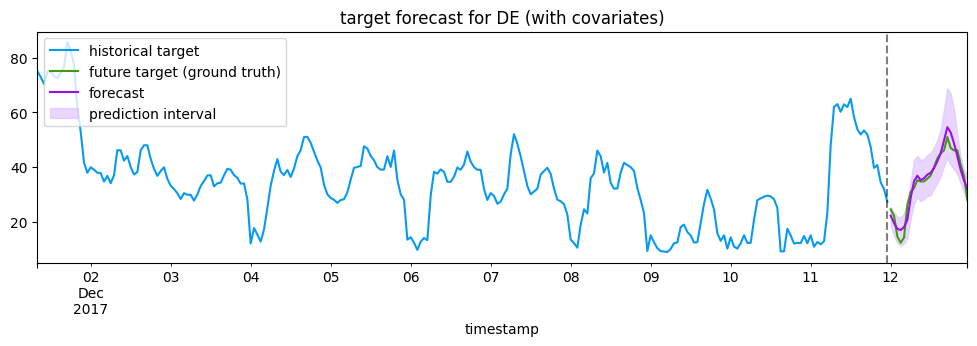

In [ ]:
# Visualize forecast with covariates
plot_forecast(
    energy_context_df,
    energy_pred_df,
    energy_test_df,
    target_column=target,
    timeseries_id=timeseries_id,
    title_suffix="(with covariates)",
)

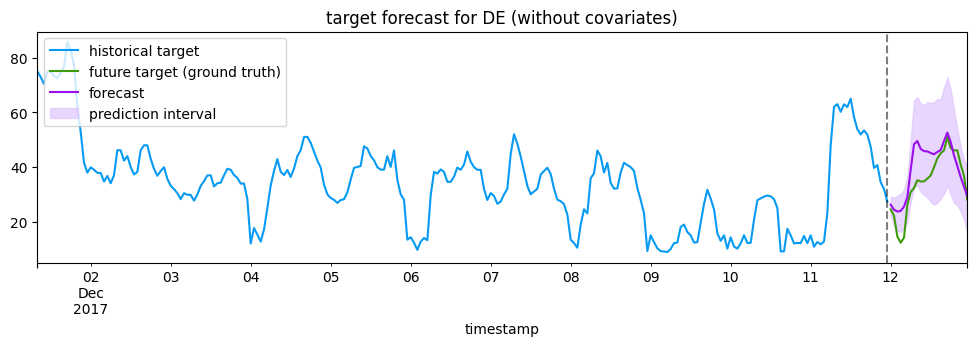

In [ ]:
# Compare: forecast without covariates
energy_pred_no_cov_df = pipeline.predict_df(
    energy_context_df[[id_column, timestamp_column, target]],
    future_df=None,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=target,
)

plot_forecast(
    energy_context_df,
    energy_pred_no_cov_df,
    energy_test_df,
    target_column=target,
    timeseries_id=timeseries_id,
    title_suffix="(without covariates)",
)

The comparison shows that Chronos-2 makes reasonable but imprecise predictions in univariate mode. However, with covariates, Chronos-2 effectively uses the load and renewable generation forecasts, producing significantly more accurate predictions.

### Retail Demand Forecasting

Forecast next quarter's weekly store sales using historical sales, historical customer footfall (Customers), and known covariates indicating store operation (Open), promotion periods (Promo), and holidays (SchoolHoliday, StateHoliday).

In [ ]:
# Retail forecasting configuration
target = "Sales"  # Column name containing sales values to forecast
prediction_length = 13  # Number of days to forecast ahead
id_column = "id"  # Column identifying different products/stores
timestamp_column = "timestamp"  # Column containing datetime information
timeseries_id = "1"  # Specific time series to visualize (product/store ID)

# Load historical sales and past values of covariates
sales_context_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/train.parquet")
sales_context_df[timestamp_column] = pd.to_datetime(sales_context_df[timestamp_column])
display(sales_context_df.head())

# Load future values of covariates
sales_test_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/test.parquet")
sales_test_df[timestamp_column] = pd.to_datetime(sales_test_df[timestamp_column])
sales_future_df = sales_test_df.drop(columns=target)
display(sales_future_df.head())

,id,timestamp,Sales,Open,Promo,SchoolHoliday,StateHoliday,Customers
0,1,2013-01-13,32952.0,0.857143,0.714286,5.0,0.0,3918.0
1,1,2013-01-20,25978.0,0.857143,0.000000,0.0,0.0,3417.0
2,1,2013-01-27,33071.0,0.857143,0.714286,0.0,0.0,3862.0
3,1,2013-02-03,28693.0,0.857143,0.000000,0.0,0.0,3561.0
4,1,2013-02-10,35771.0,0.857143,0.714286,0.0,0.0,4094.0


,id,timestamp,Open,Promo,SchoolHoliday,StateHoliday
0,1,2015-05-03,0.714286,0.714286,0.0,1.0
1,1,2015-05-10,0.857143,0.714286,0.0,0.0
2,1,2015-05-17,0.714286,0.000000,0.0,1.0
3,1,2015-05-24,0.857143,0.714286,0.0,0.0
4,1,2015-05-31,0.714286,0.000000,0.0,1.0


In [ ]:
# Generate predictions with covariates
sales_pred_df = pipeline.predict_df(
    sales_context_df,
    future_df=sales_future_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=target,
)
display(sales_pred_df.head())

,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,1,2015-05-03,Sales,28939.392578,25214.277344,28939.392578,32411.097656
1,1,2015-05-10,Sales,25541.919922,21921.324219,25541.919922,29191.929688
2,1,2015-05-17,Sales,23640.238281,20500.339844,23640.238281,26884.666016
3,1,2015-05-24,Sales,26778.261719,23318.355469,26778.261719,30162.820312
4,1,2015-05-31,Sales,22679.361328,19722.287109,22679.361328,25990.042969


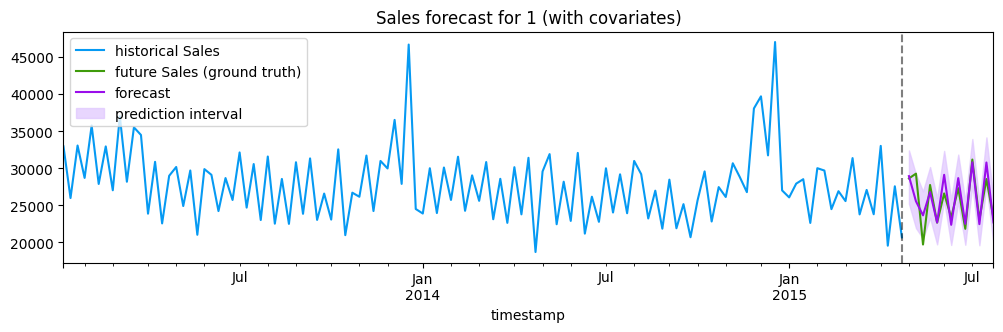

In [ ]:
# Visualize forecast with covariates
plot_forecast(
    sales_context_df,
    sales_pred_df,
    sales_test_df,
    target_column=target,
    timeseries_id=timeseries_id,
    title_suffix="(with covariates)",
)

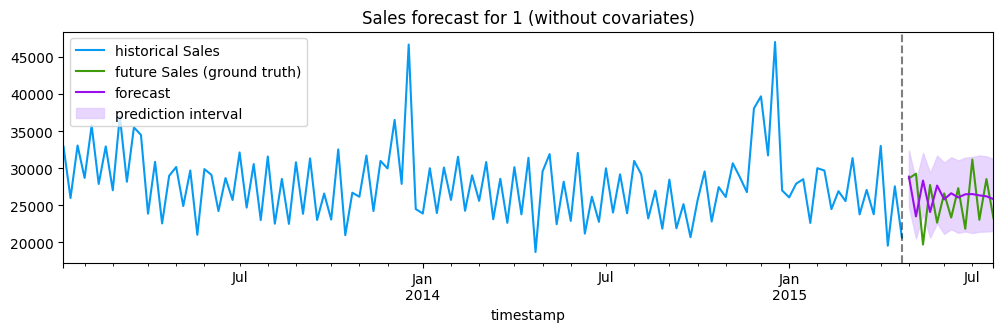

In [ ]:
# Compare: forecast without covariates
sales_pred_no_cov_df = pipeline.predict_df(
    sales_context_df[[id_column, timestamp_column, target]],
    future_df=None,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=target,
)

plot_forecast(
    sales_context_df,
    sales_pred_no_cov_df,
    sales_test_df,
    target_column=target,
    timeseries_id=timeseries_id,
    title_suffix="(without covariates)",
)

Chronos-2's univariate forecast is nearly flat with high uncertainty. In contrast, the forecast with covariates leverages promotion and holiday information to capture the true sales dynamics over the forecast horizon.

## Cross-Learning with Joint Prediction

Chronos-2 supports **cross-learning** through the `cross_learning=True` parameter, which enables the model to share information across all time series in a batch during prediction. This can be particularly beneficial when forecasting multiple related time series with short historical context.

In [ ]:
# Example: Enable cross-learning for joint prediction
# This assigns the same group ID to all time series, allowing information sharing
joint_pred_df = pipeline.predict_df(
    context_df,
    prediction_length=24,
    quantile_levels=[0.1, 0.5, 0.9],
    cross_learning=True,  # Enable cross-learning
    batch_size=100,
)

<div class="alert alert-info alert-light" role="alert">

### Important Considerations for Cross-Learning

When using `cross_learning=True`, keep these caveats in mind:

- **Task-dependent results**: Cross-learning may not always improve forecasts and could worsen performance for some tasks. Evaluate this feature for your specific use case.

- **Batch size dependency**: Results become dependent on batch size. Very large batch sizes may not provide benefits as they deviate from the maximum group size used during pretraining. For optimal results, consider using a batch size around 100 (as used in the paper).

- **Input homogeneity**: This feature works best with homogeneous inputs (e.g., multiple univariate time series of the same type). Mixing different task types may lead to unexpected behavior.

- **Short context benefit**: Cross-learning is most helpful when individual time series have limited historical context, as the model can leverage patterns from related series in the batch.

</div>

## (Advanced) Numpy/torch API

For advanced use cases, Chronos-2 provides a lower-level numpy/torch API via the `predict_quantiles` method.

The `predict_quantiles` method accepts:
- `inputs`: Time series to forecast (see formats below)
- `prediction_length`: Number of timesteps to forecast
- `quantile_levels`: List of quantiles to compute

Two input formats are supported:
1. **3D array**: `(batch_size, num_variates, history_length)` for forecasting without covariates
2. **List of dicts**: Each dict contains:
   - `target`: 1D or 2D array of shape `(history_length,)` or `(num_variates, history_length)`
   - `past_covariates` (optional): Dict mapping covariate names to 1D arrays of length `history_length`
   - `future_covariates` (optional): Dict mapping covariate names to 1D arrays of length `prediction_length`

In [ ]:
# Univariate forecasting
inputs = np.random.randn(32, 1, 100)
quantiles, mean = pipeline.predict_quantiles(
    inputs, prediction_length=24, quantile_levels=[0.1, 0.5, 0.9]
)
print("Univariate output shapes:", quantiles[0].shape, mean[0].shape)

Univariate output shapes: torch.Size([1, 24, 3]) torch.Size([1, 24])


In [ ]:
# Multivariate forecasting
inputs = np.random.randn(32, 3, 512)
quantiles, mean = pipeline.predict_quantiles(
    inputs, prediction_length=48, quantile_levels=[0.1, 0.5, 0.9]
)
print("Multivariate output shapes:", quantiles[0].shape, mean[0].shape)

Multivariate output shapes: torch.Size([3, 48, 3]) torch.Size([3, 48])


In [ ]:
# Univariate forecasting with covariates
prediction_length = 64
inputs = [
    {
        "target": np.random.randn(200),
        "past_covariates": {"temperature": np.random.randn(200), "precipitation": np.random.randn(200)},
        "future_covariates": {"temperature": np.random.randn(prediction_length)},
    }
    for _ in range(16)
]
quantiles, mean = pipeline.predict_quantiles(
    inputs, prediction_length=prediction_length, quantile_levels=[0.1, 0.5, 0.9]
)
print("Univariate with covariates output shapes:", quantiles[0].shape, mean[0].shape)

Univariate with covariates output shapes: torch.Size([1, 64, 3]) torch.Size([1, 64])


In [ ]:
# Multivariate forecasting with categorical covariates
prediction_length = 96
inputs = [
    {
        "target": np.random.randn(2, 1000),
        "past_covariates": {
            "temperature": np.random.randn(1000),
            "weather_type": np.random.choice(["sunny", "cloudy", "rainy"], size=1000),
        },
        "future_covariates": {
            "temperature": np.random.randn(prediction_length),
            "weather_type": np.random.choice(["sunny", "cloudy", "rainy"], size=prediction_length),
        },
    }
    for _ in range(10)
]
quantiles, mean = pipeline.predict_quantiles(
    inputs, prediction_length=prediction_length, quantile_levels=[0.1, 0.5, 0.9]
)
print("Multivariate with categorical covariates output shapes:", quantiles[0].shape, mean[0].shape)

Multivariate with categorical covariates output shapes: torch.Size([2, 96, 3]) torch.Size([2, 96])


## Fine-Tuning

Chronos-2 supports fine-tuning on your own data. You may either fine-tune all weights of the model (_full fine-tuning_) or a [low rank adapter (LoRA)](https://huggingface.co/docs/peft/en/package_reference/lora), which significantly reduces the number of trainable parameters.

<div class="alert alert-warning alert-light" role="alert">

**Note:** Fine-tuning functionality is intended for advanced users. The default fine-tuning hyperparameters may not always improve accuracy for your specific use case. We recommend experimenting with different hyperparameters. In case of limited data (too few and/or too short series), fine-tuning may not improve over zero-shot (and may even worsen accuracy sometimes).

</div>

### Fine-Tuning API

The `fit` method accepts:
- `inputs`: Time series for fine-tuning (same format as predict_quantiles)
- `finetune_mode`: `"full"` or `"lora"`
- `lora_config`: The [`LoraConfig`](https://huggingface.co/docs/peft/en/package_reference/lora#peft.LoraConfig), in case `finetune_mode="lora"`
- `prediction_length`: Forecast horizon for fine-tuning
- `validation_inputs`: Optional validation data (same format as inputs)
- `learning_rate`: Optimizer learning rate (default: 1e-6, we recommend a higher learning rate such as 1e-5 for LoRA)
- `num_steps`: Number of training steps (default: 1000)
- `batch_size`: Batch size for training (default: 256)

Returns a new pipeline with the fine-tuned model.

Please read the docstring for details about specific arguments.

In [ ]:
from chronos.chronos2 import preprocess

# Prepare data for fine-tuning using the retail sales dataset
train_inputs = preprocess.from_data_frame(
    sales_context_df,
    target_columns=[target],
    prediction_length=prediction_length,
    id_column=id_column,
    timestamp_column=timestamp_column,
    known_covariates_names=["Open", "Promo", "SchoolHoliday", "StateHoliday"],
    # Remaining columns are treated as past-only covariates
)

In [ ]:
# Fine-tune the model by default full fine-tuning will be performed
finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=13,
    num_steps=1000,
    learning_rate=1e-5,
    batch_size=32,
    logging_steps=100,
)

Step,Training Loss
100,0.645235
200,0.531210
300,0.506029
400,0.463864
500,0.457992
600,0.523888
700,0.460553
800,0.431011
900,0.443293
1000,0.501886


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

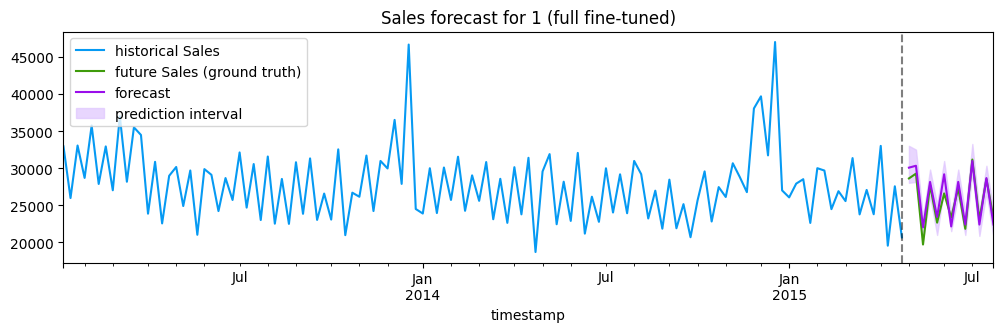

In [ ]:
# Use the fine-tuned model for predictions
finetuned_pred_df = finetuned_pipeline.predict_df(
    sales_context_df,
    future_df=sales_future_df,
    prediction_length=13,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="Sales",
)

plot_forecast(
    sales_context_df,
    finetuned_pred_df,
    sales_test_df,
    target_column="Sales",
    timeseries_id="1",
    title_suffix="(full fine-tuned)",
)

In [ ]:
# Fine-tune the model with LoRA
lora_finetuned_pipeline = pipeline.fit(
    inputs=train_inputs,
    prediction_length=13,
    num_steps=1000,
    learning_rate=1e-4,
    batch_size=32,
    logging_steps=100,
    finetune_mode="lora",
)

Step,Training Loss
100,0.751987
200,0.617841
300,0.596480
400,0.539733
500,0.544369
600,0.605739
700,0.546832
800,0.511915
900,0.537151
1000,0.583478


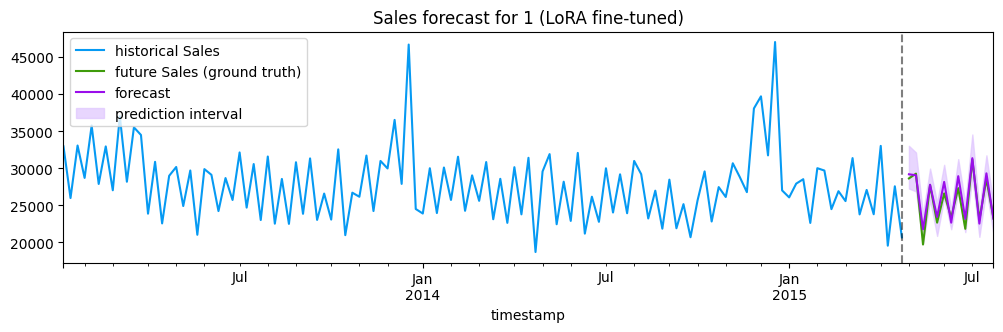

In [ ]:
# Use the LoRA fine-tuned model for predictions
lora_finetuned_pred_df = lora_finetuned_pipeline.predict_df(
    sales_context_df,
    future_df=sales_future_df,
    prediction_length=13,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="Sales",
)

plot_forecast(
    sales_context_df,
    lora_finetuned_pred_df,
    sales_test_df,
    target_column="Sales",
    timeseries_id="1",
    title_suffix="(LoRA fine-tuned)",
)